Regression Diagnostics and Spatial Residual Analysis


The section then produces:

 -residual-versus-fitted plots;
 -Q–Q plots;
 -Breusch–Pagan tests;
 -Variance Inflation Factors;
 -Cook's Distance;
 -influential-authority sensitivity models;
 -Urbanity sensitivity comparisons;
 -residual maps using the GeoJSON boundaries;
 -Global Moran's I of OLS residuals;
 -Local Moran's I residual clusters;
 -corrected diagnostic Excel and GeoPackage outputs.

All Google Drive paths use **Final Main 3**.


# #SECTION 4.1 - INSTALL REQUIRED SPATIAL LIBRARIES


In [ ]:

 #Install packages required for geographic residual analysis.



!pip install geopandas libpysal esda mapclassify openpyxl -q

print("Required libraries installed.")


Required libraries installed.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# #SECTION 4.2 - IMPORT DIAGNOSTIC AND SPATIAL LIBRARIES


In [ ]:

 #Import packages for:
 #-OLS regression;
 #-residual diagnostics;
 #-heteroscedasticity testing;
 #-multicollinearity analysis;
 #-influential-observation analysis;
 #-geographic processing;
 #-Global and Local Moran's I;



import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.formula.api as smf

from scipy import stats

from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import (
    variance_inflation_factor,
    OLSInfluence
)

import geopandas as gpd

from shapely import wkt
from shapely.validation import make_valid

from libpysal.weights import Queen, KNN
from esda.moran import Moran, Moran_Local

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option(
    "display.float_format",
    lambda value: f"{value:.4f}"
)

print("Diagnostic and spatial libraries imported successfully.")


Diagnostic and spatial libraries imported successfully.


# #SECTION 4.3 - LOAD THE FINAL LA DATASET DIRECTLY


In [ ]:

 #Load the authoritative final Local Authority dataset.




FINAL_LA_PATH = (
    "/content/drive/MyDrive/MSC Dissertation/"
    "Final Main 3/LA/Final_LA_data.xlsx"
)

if not os.path.exists(FINAL_LA_PATH):

    raise FileNotFoundError(
        "Final LA dataset not found."
        "Check FINAL_LA_PATH."
    )

la_analysis = pd.read_excel(
    FINAL_LA_PATH
)

print("Final LA dataset loaded successfully.")
print(f"Dataset shape: {la_analysis.shape}")

display(
    la_analysis.head()
)


Final LA dataset loaded successfully.
Dataset shape: (294, 23)


,LA Authority,LA to LEA Mapped,Urbanity,Total no of pupils,Total no of Schools,Average SEN Rate,Average EHC Rate,Average Total SEND Rate,Average IMD Score,Average Income Score Rate,Average Employment Score,"Average Education, Skills and Training Score",Average Income Deprivation Affecting Children Index (IDACI) Score (rate),Total Population,Total Dependent child Population (0-15),Total working age Population (18-66),No of \nspecial schools,geo-Political Zone,new_la_code,district_administrative_code,LAD24NM,LAD24CD,geometry
0,Adur,West Sussex,1,9099,21,0.1738,0.1415,0.3153,14.9620,0.1833,0.1151,22.6790,0.2753,64725,11704,37632,2,South East,E10000032,E07000223,Adur,E07000223,"MULTIPOLYGON (((-0.279155 50.829507, -0.280235..."
1,Amber Valley,Derbyshire,1,18726,73,0.1491,0.1004,0.2495,18.7127,0.1919,0.1314,21.9658,0.3013,126934,21150,77288,5,East Midlands,E10000007,E07000032,Amber Valley,E07000032,"POLYGON ((-1.495366 53.133965, -1.493616 53.13..."
2,Arun,West Sussex,1,18895,46,0.1442,0.1105,0.2547,19.3290,0.1900,0.1179,25.4335,0.3292,166381,25398,94293,2,South East,E10000032,E07000224,Arun,E07000224,"MULTIPOLYGON (((-0.749958 50.756688, -0.750031..."
3,Ashfield,Nottinghamshire,1,19899,49,0.1211,0.0960,0.2171,25.8176,0.2617,0.1749,30.6790,0.4113,127101,23467,78109,4,East Midlands,E10000024,E07000170,Ashfield,E07000170,"POLYGON ((-1.284152 53.168382, -1.281992 53.16..."
4,Ashford,Kent,2,23207,62,0.1273,0.1621,0.2895,19.8691,0.2037,0.1202,22.2792,0.3054,135741,26712,81863,8,South East,E10000016,E07000105,Ashford,E07000105,"POLYGON ((0.955032 51.270246, 0.958151 51.2685..."


# #SECTION 4.4 - CLEAN COLUMN NAMES AND VERIFY 294 AUTHORITIES


In [ ]:

 #Remove hidden line breaks and repeated spaces from column names.


la_analysis.columns = (
    la_analysis.columns
    .str.replace(
        "\n",
        " ",
        regex=False
    )
    .str.replace(
        r"\s+",
        " ",
        regex=True
    )
    .str.strip()
)

EXPECTED_LA_COUNT = 294

print(
    "Rows in final LA dataset:",
    len(la_analysis)
)

if len(la_analysis) != EXPECTED_LA_COUNT:

    raise ValueError(
        f"Expected {EXPECTED_LA_COUNT} Local Authorities, "
        f"but found {len(la_analysis)}."
    )

print("PASS: Final dataset contains all 294 Local Authorities.")


Rows in final LA dataset: 294
PASS: Final dataset contains all 294 Local Authorities.


# #SECTION 4.5 - RECREATE THE URBANITY CATEGORY CORRECTLY


In [ ]:

 #Derive Urbanity Category directly from the numeric Urbanity field.


 #Numeric coding:
 #1 = Most Urban
 #2 = Moderately Urban
 #3 = Moderately Rural
 #4 = Most Rural


URBANITY_MAP = {
    1: "Most Urban",
    2: "Moderately Urban",
    3: "Moderately Rural",
    4: "Most Rural"
}

URBANITY_ORDER = [
    "Most Urban",
    "Moderately Urban",
    "Moderately Rural",
    "Most Rural"
]

la_analysis["Urbanity"] = pd.to_numeric(
    la_analysis["Urbanity"],
    errors="coerce"
)

la_analysis["Urbanity Category"] = (
    la_analysis["Urbanity"]
    .map(
        URBANITY_MAP
    )
)

la_analysis["Urbanity Category"] = pd.Categorical(
    la_analysis["Urbanity Category"],
    categories=URBANITY_ORDER,
    ordered=False
)

urbanity_counts = (
    la_analysis[
        "Urbanity Category"
    ]
    .value_counts(
        dropna=False
    )
    .reindex(
        URBANITY_ORDER
    )
)

print("Corrected Urbanity distribution:")
display(
    urbanity_counts
    .rename("Number of LAs")
    .to_frame()
)

expected_urbanity_counts = {
    "Most Urban": 178,
    "Moderately Urban": 45,
    "Moderately Rural": 38,
    "Most Rural": 33
}

for category, expected_count in expected_urbanity_counts.items():

    actual_count = int(
        urbanity_counts.loc[
            category
        ]
    )

    if actual_count != expected_count:

        raise ValueError(
            f"Urbanity validation failed for {category}: "
            f"expected {expected_count}, found {actual_count}."
        )

print(
    "PASS: Urbanity categories total 294 and match the "
    "expected 178/45/38/33 distribution."
)


Corrected Urbanity distribution:


,Number of LAs
Urbanity Category,
Most Urban,178
Moderately Urban,45
Moderately Rural,38
Most Rural,33


PASS: Urbanity categories total 294 and match the expected 178/45/38/33 distribution.


# #SECTION 4.6 - RECREATE DERIVED SECTION 4 PREDICTORS


In [ ]:

 #Rebuild the contextual variables used in the
 #extended OLS models directly from the final LA dataset.
#
 #Derived variables:
 #-Child Population Percentage
 #-Schools per 10,000 Pupils
 #-Special Schools per 10,000 Pupils
 #-Pupils as Percentage of Population


NUMERIC_SOURCE_COLUMNS = [
    "Total no of pupils",
    "Total no of Schools",
    "Average SEN Rate",
    "Average EHC Rate",
    "Average Total SEND Rate",
    "Average IMD Score",
    "Average Income Score Rate",
    "Average Employment Score",
    "Average Education, Skills and Training Score",
    (
        "Average Income Deprivation Affecting Children "
        "Index (IDACI) Score (rate)"
    ),
    "Total Population",
    "Total Dependent child Population (0-15)",
    "Total working age Population (18-66)",
    "No of special schools"
]

for column in NUMERIC_SOURCE_COLUMNS:

    if column not in la_analysis.columns:

        raise KeyError(
            f"Required final-LA column missing: {column}"
        )

    la_analysis[column] = pd.to_numeric(
        la_analysis[column],
        errors="coerce"
    )


def safe_divide(
    numerator,
    denominator
):
    """
    Divide while protecting against zero denominators.
    """

    return (
        numerator
        /
        denominator.replace(
            0,
            np.nan
        )
    )


la_analysis[
    "Child Population Percentage"
] = (
    safe_divide(
        la_analysis[
            "Total Dependent child Population (0-15)"
        ],
        la_analysis[
            "Total Population"
        ]
    )
    * 100
)

la_analysis[
    "Schools per 10,000 Pupils"
] = (
    safe_divide(
        la_analysis[
            "Total no of Schools"
        ],
        la_analysis[
            "Total no of pupils"
        ]
    )
    * 10000
)

la_analysis[
    "Special Schools per 10,000 Pupils"
] = (
    safe_divide(
        la_analysis[
            "No of special schools"
        ],
        la_analysis[
            "Total no of pupils"
        ]
    )
    * 10000
)

la_analysis[
    "Pupils as Percentage of Population"
] = (
    safe_divide(
        la_analysis[
            "Total no of pupils"
        ],
        la_analysis[
            "Total Population"
        ]
    )
    * 100
)

print("Section 4 derived predictors recreated successfully.")

display(
    la_analysis[
        [
            "Child Population Percentage",
            "Schools per 10,000 Pupils",
            "Special Schools per 10,000 Pupils",
            "Pupils as Percentage of Population"
        ]
    ]
    .describe()
    .T
    .round(4)
)


Section 4 derived predictors recreated successfully.


,count,mean,std,min,25%,50%,75%,max
Child Population Percentage,294.0000,18.2485,2.0698,12.7667,16.6974,18.2121,19.6946,25.8581
"Schools per 10,000 Pupils",294.0000,28.8592,7.5878,14.0322,23.3403,27.6541,33.0314,68.7214
"Special Schools per 10,000 Pupils",294.0000,2.1807,1.1788,0.0000,1.4017,1.9828,2.7625,6.0000
Pupils as Percentage of Population,294.0000,15.6518,2.2485,10.9283,14.0645,15.3216,17.1119,23.1848


# #SECTION 4.7 - PREPARE REGION AND VALIDATE ALL MODEL VARIABLES


In [ ]:

 #Prepare English region as a categorical predictor and confirm that
 #every variable required by the extended OLS model exists.


REGION_ORDER = sorted(
    la_analysis[
        "geo-Political Zone"
    ]
    .dropna()
    .astype(str)
    .unique()
    .tolist()
)

la_analysis[
    "geo-Political Zone"
] = pd.Categorical(
    la_analysis[
        "geo-Political Zone"
    ],
    categories=REGION_ORDER,
    ordered=False
)

LA_OUTCOMES = [
    "Average SEN Rate",
    "Average EHC Rate",
    "Average Total SEND Rate"
]

EXTENDED_NUMERIC_PREDICTORS = [
    "Average IMD Score",
    "Average Income Score Rate",
    "Average Employment Score",
    "Average Education, Skills and Training Score",
    (
        "Average Income Deprivation Affecting Children "
        "Index (IDACI) Score (rate)"
    ),
    "Child Population Percentage",
    "Schools per 10,000 Pupils",
    "Special Schools per 10,000 Pupils",
    "Pupils as Percentage of Population"
]

EXTENDED_CATEGORICAL_PREDICTORS = [
    "Urbanity Category",
    "geo-Political Zone"
]

REQUIRED_MODEL_COLUMNS = list(
    dict.fromkeys(
        LA_OUTCOMES
        + EXTENDED_NUMERIC_PREDICTORS
        + EXTENDED_CATEGORICAL_PREDICTORS
        + [
            "LA Authority",
            "district_administrative_code"
        ]
    )
)

missing_model_columns = [
    column
    for column in REQUIRED_MODEL_COLUMNS
    if column not in la_analysis.columns
]

if missing_model_columns:

    raise KeyError(
        "Required diagnostic variables are missing: "
        f"{missing_model_columns}"
    )

missing_report = (
    la_analysis[
        REQUIRED_MODEL_COLUMNS
    ]
    .isna()
    .sum()
    .rename(
        "Missing Values"
    )
    .to_frame()
)

display(
    missing_report
)

model_missing_total = int(
    missing_report[
        "Missing Values"
    ].sum()
)

if model_missing_total != 0:

    raise ValueError(
        "The corrected Section 5 model variables contain missing "
        f"values ({model_missing_total} total)."
        "Investigate before continuing."
    )

if len(la_analysis) != EXPECTED_LA_COUNT:

    raise ValueError(
        f"The regression dataset contains {len(la_analysis)} rows "
        f"instead of {EXPECTED_LA_COUNT}."
    )

print(
    "PASS: All Section 5 regression variables are complete "
    "for all 294 LAs."
)


,Missing Values
Average SEN Rate,0
Average EHC Rate,0
Average Total SEND Rate,0
Average IMD Score,0
Average Income Score Rate,0
Average Employment Score,0
"Average Education, Skills and Training Score",0
Average Income Deprivation Affecting Children Index (IDACI) Score (rate),0
Child Population Percentage,0
"Schools per 10,000 Pupils",0


PASS: All Section 5 regression variables are complete for all 294 LAs.


# #SECTION 4.8 - CREATE SAFE STATSMODELS VARIABLE NAMES


In [ ]:

 #Rename model variables in a separate dataframe so that OLS
 #formulas remain readable and robust to spaces and punctuation.


OLS_RENAME_MAP = {
    "Average SEN Rate":
        "sen_rate",

    "Average EHC Rate":
        "ehc_rate",

    "Average Total SEND Rate":
        "total_send_rate",

    "Average IMD Score":
        "imd_score",

    "Average Income Score Rate":
        "income_score",

    "Average Employment Score":
        "employment_score",

    "Average Education, Skills and Training Score":
        "education_score",

    (
        "Average Income Deprivation Affecting Children "
        "Index (IDACI) Score (rate)"
    ):
        "idaci_score",

    "Child Population Percentage":
        "child_population_pct",

    "Schools per 10,000 Pupils":
        "schools_per_10000",

    "Special Schools per 10,000 Pupils":
        "special_schools_per_10000",

    "Pupils as Percentage of Population":
        "pupils_population_pct",

    "Urbanity Category":
        "urbanity_category",

    "geo-Political Zone":
        "region"
}

diagnostic_data = (
    la_analysis.rename(
        columns=OLS_RENAME_MAP
    )
    .copy()
)

OUTCOME_SAFE_NAMES = {
    "Average SEN Rate":
        "sen_rate",

    "Average EHC Rate":
        "ehc_rate",

    "Average Total SEND Rate":
        "total_send_rate"
}

EXTENDED_PREDICTOR_FORMULA = """
imd_score
+ income_score
+ employment_score
+ education_score
+ idaci_score
+ child_population_pct
+ schools_per_10000
+ special_schools_per_10000
+ pupils_population_pct
+ C(urbanity_category, Treatment(reference="Most Urban"))
+ C(region)
"""

EXTENDED_OLS_FORMULAS = {
    original_outcome:
        f"{safe_outcome} ~ {EXTENDED_PREDICTOR_FORMULA}"

    for original_outcome, safe_outcome
    in OUTCOME_SAFE_NAMES.items()
}

print("Corrected extended OLS formulas created.")


Corrected extended OLS formulas created.


# #SECTION 4.9 - FIT THE FULL-SAMPLE EXTENDED OLS MODELS


In [ ]:



diagnostic_ols_models = {}

for outcome, formula in (
    EXTENDED_OLS_FORMULAS.items()
):

    fitted_model = smf.ols(
        formula=formula,
        data=diagnostic_data
    ).fit()

    diagnostic_ols_models[
        outcome
    ] = fitted_model

    print("=" * 90)
    print(
        f"FULL-SAMPLE DIAGNOSTIC OLS: {outcome}"
    )
    print("=" * 90)

    print(
        "Observations:",
        int(
            fitted_model.nobs
        )
    )

    print(
        "R-squared:",
        round(
            fitted_model.rsquared,
            4
        )
    )

    print(
        "Adjusted R-squared:",
        round(
            fitted_model.rsquared_adj,
            4
        )
    )

    if int(
        fitted_model.nobs
    ) != EXPECTED_LA_COUNT:

        raise ValueError(
            f"{outcome} used {int(fitted_model.nobs)} observations "
            f"instead of {EXPECTED_LA_COUNT}."
            "STOP: do not use the diagnostic outputs."
        )

print(
    "\nPASS: All three diagnostic OLS models use exactly 294 LAs."
)


FULL-SAMPLE DIAGNOSTIC OLS: Average SEN Rate
Observations: 294
R-squared: 0.3694
Adjusted R-squared: 0.3232
FULL-SAMPLE DIAGNOSTIC OLS: Average EHC Rate
Observations: 294
R-squared: 0.6959
Adjusted R-squared: 0.6737
FULL-SAMPLE DIAGNOSTIC OLS: Average Total SEND Rate
Observations: 294
R-squared: 0.5834
Adjusted R-squared: 0.5529

PASS: All three diagnostic OLS models use exactly 294 LAs.


# #SECTION 4.10 - VERIFY URBANITY TERMS IN THE MODEL


In [ ]:

 #Confirm that all three non-reference Urbanity categories appear
 #in each OLS design matrix.



EXPECTED_URBANITY_TERMS = [
    "Moderately Urban",
    "Moderately Rural",
    "Most Rural"
]

for outcome, fitted_model in (
    diagnostic_ols_models.items()
):

    model_terms = (
        fitted_model.params.index
        .tolist()
    )

    print(
        "\n",
        outcome
    )

    for category in EXPECTED_URBANITY_TERMS:

        matching_terms = [
            term
            for term in model_terms
            if (
                "urbanity_category"
                in term
                and
                category
                in term
            )
        ]

        if not matching_terms:

            raise ValueError(
                f"Urbanity term missing from {outcome}: {category}"
            )

        print(
            "PASS:",
            category,
            "is represented in the model."
        )



 Average SEN Rate
PASS: Moderately Urban is represented in the model.
PASS: Moderately Rural is represented in the model.
PASS: Most Rural is represented in the model.

 Average EHC Rate
PASS: Moderately Urban is represented in the model.
PASS: Moderately Rural is represented in the model.
PASS: Most Rural is represented in the model.

 Average Total SEND Rate
PASS: Moderately Urban is represented in the model.
PASS: Moderately Rural is represented in the model.
PASS: Most Rural is represented in the model.


# #SECTION 4.11 - CREATE RESIDUAL DIAGNOSTIC TABLES


In [ ]:

 #Store:
 #-observed outcomes;
 #-fitted outcomes;
 #-raw residuals;
 #-standardised residuals;
 #-authority names;
 #-district administrative codes.
#
 #district_administrative_code is retained because Section 5.23
 #joins the Excel data to the GeoJSON using:
#
 #GeoJSON LAD24CD = Excel district_administrative_code
#
 #Each residual table must contain all 294 authorities.


diagnostic_result_tables = {}

for outcome, fitted_model in (
    diagnostic_ols_models.items()
):

    row_labels = (
        fitted_model.model.data.row_labels
    )

    influence = (
        fitted_model.get_influence()
    )

    result_table = pd.DataFrame({
        "LA Authority":
            diagnostic_data.loc[
                row_labels,
                "LA Authority"
            ].values,

        "district_administrative_code":
            diagnostic_data.loc[
                row_labels,
                "district_administrative_code"
            ].values,

        "Observed":
            fitted_model.model.endog,

        "Fitted":
            fitted_model.fittedvalues.values,

        "Residual":
            fitted_model.resid.values,

        "Standardised Residual":
            influence.resid_studentized_internal
    })

    result_table[
        "district_administrative_code"
    ] = (
        result_table[
            "district_administrative_code"
        ]
        .astype(str)
        .str.strip()
        .str.upper()
    )

    if len(
        result_table
    ) != EXPECTED_LA_COUNT:

        raise ValueError(
            f"Residual table for {outcome} contains "
            f"{len(result_table)} rows instead of 294."
        )

    if (
        result_table[
            "district_administrative_code"
        ]
        .nunique()
        != EXPECTED_LA_COUNT
    ):

        raise ValueError(
            f"Residual table for {outcome} does not contain "
            "294 unique district administrative codes."
        )

    diagnostic_result_tables[
        outcome
    ] = result_table

    print(
        f"{outcome}: residual table contains "
        f"{len(result_table)} LAs."
    )


Average SEN Rate: residual table contains 294 LAs.
Average EHC Rate: residual table contains 294 LAs.
Average Total SEND Rate: residual table contains 294 LAs.


# #SECTION 4.12 - PLOT RESIDUALS AGAINST FITTED VALUES


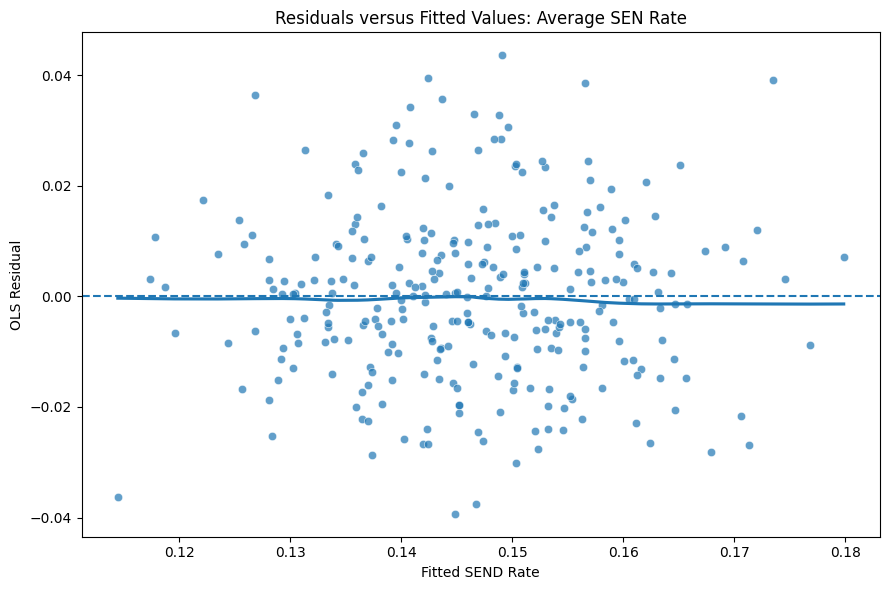

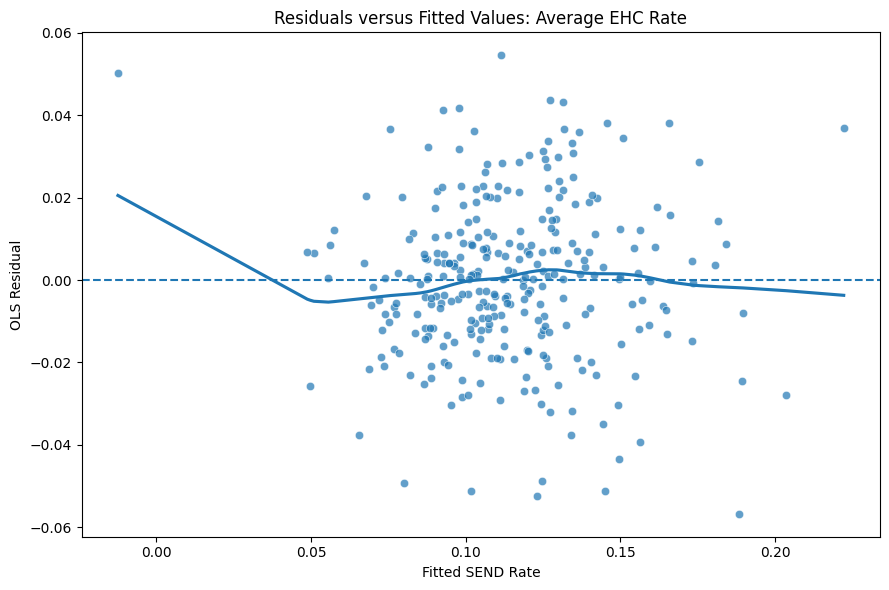

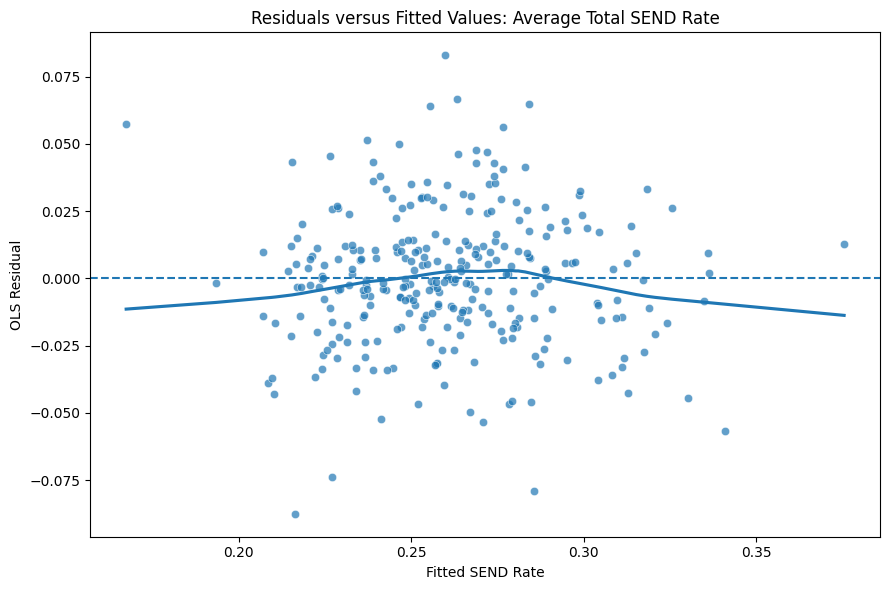

In [ ]:

 #Assess:
 #-linearity;
 #-constant variance;
 #-unusual residual patterns.



for outcome, table in (
    diagnostic_result_tables.items()
):

    plt.figure(
        figsize=(9, 6)
    )

    sns.scatterplot(
        data=table,
        x="Fitted",
        y="Residual",
        alpha=0.70
    )

    plt.axhline(
        0,
        linestyle="--",
        linewidth=1.5
    )

    sns.regplot(
        data=table,
        x="Fitted",
        y="Residual",
        scatter=False,
        lowess=True
    )

    plt.title(
        f"Residuals versus Fitted Values: {outcome}"
    )

    plt.xlabel(
        "Fitted SEND Rate"
    )

    plt.ylabel(
        "OLS Residual"
    )

    plt.tight_layout()
    plt.show()


# #SECTION 4.13 - CREATE RESIDUAL Q-Q PLOTS


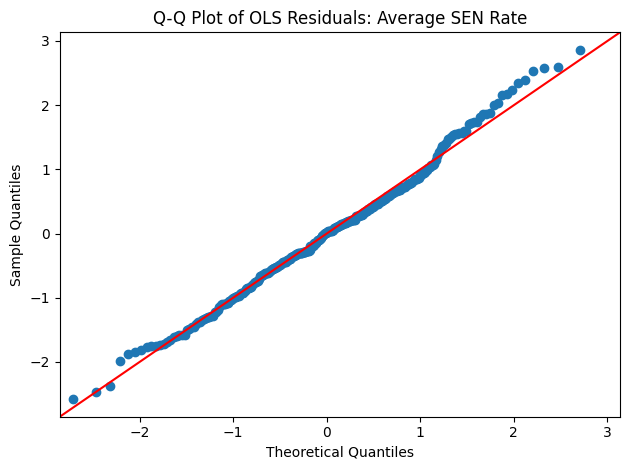

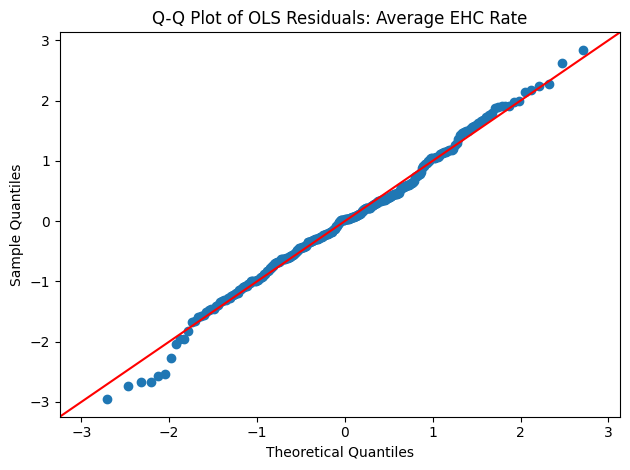

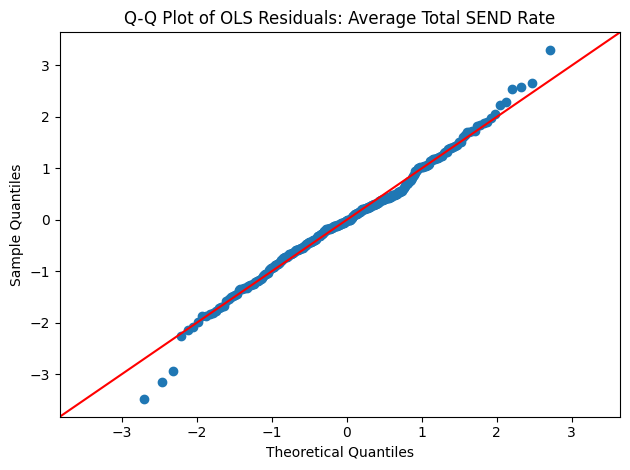

In [ ]:

 #Compare OLS residuals with a theoretical normal distribution.

 #Points close to the diagonal line indicate approximate normality.
 #Tail departures may indicate skewness or influential authorities.


import statsmodels.api as sm

for outcome, fitted_model in (
    diagnostic_ols_models.items()
):

    sm.qqplot(
        fitted_model.resid,
        line="45",
        fit=True
    )

    plt.title(
        f"Q-Q Plot of OLS Residuals: {outcome}"
    )

    plt.tight_layout()
    plt.show()


# #SECTION 4.14 - SUMMARize RESIDUAL DISTRIBUTIONS


In [ ]:

 #Calculate residual:
 #-mean;
 #-standard deviation;
 #-skewness;
 #-excess kurtosis.



residual_distribution_rows = []

for outcome, fitted_model in (
    diagnostic_ols_models.items()
):

    residuals = (
        fitted_model.resid
    )

    residual_distribution_rows.append({
        "Outcome":
            outcome,

        "Observations":
            int(
                fitted_model.nobs
            ),

        "Residual Mean":
            residuals.mean(),

        "Residual Standard Deviation":
            residuals.std(),

        "Residual Skewness":
            stats.skew(
                residuals
            ),

        "Residual Excess Kurtosis":
            stats.kurtosis(
                residuals
            )
    })

residual_distribution_table = pd.DataFrame(
    residual_distribution_rows
)

display(
    residual_distribution_table.round(4)
)


,Outcome,Observations,Residual Mean,Residual Standard Deviation,Residual Skewness,Residual Excess Kurtosis
0,Average SEN Rate,294,0.0000,0.0153,0.2309,0.0208
1,Average EHC Rate,294,0.0000,0.0192,-0.0380,0.3034
2,Average Total SEND Rate,294,0.0000,0.0251,-0.0203,0.7381


# #SECTION 4.15 - BREUSCH-PAGAN HETEROSCEDASTICITY TEST


In [ ]:

 #Test whether residual variance is constant.

 #Null hypothesis:
 #Residual variance is constant.

 #p < 0.05 suggests heteroscedasticity.




breusch_pagan_rows = []

for outcome, fitted_model in (
    diagnostic_ols_models.items()
):

    bp_result = het_breuschpagan(
        fitted_model.resid,
        fitted_model.model.exog
    )

    lm_statistic = bp_result[0]
    lm_p_value = bp_result[1]
    f_statistic = bp_result[2]
    f_p_value = bp_result[3]

    breusch_pagan_rows.append({
        "Outcome":
            outcome,

        "Observations":
            int(
                fitted_model.nobs
            ),

        "LM Statistic":
            lm_statistic,

        "LM p-value":
            lm_p_value,

        "F Statistic":
            f_statistic,

        "F p-value":
            f_p_value,

        "Interpretation":
            (
                "Evidence of heteroscedasticity"
                if lm_p_value < 0.05
                else
                "No significant evidence of heteroscedasticity"
            )
    })

breusch_pagan_table = pd.DataFrame(
    breusch_pagan_rows
)

display(
    breusch_pagan_table.round(4)
)


,Outcome,Observations,LM Statistic,LM p-value,F Statistic,F p-value,Interpretation
0,Average SEN Rate,294,18.2716,0.5695,0.9045,0.5817,No significant evidence of heteroscedasticity
1,Average EHC Rate,294,28.2944,0.1026,1.4536,0.0976,No significant evidence of heteroscedasticity
2,Average Total SEND Rate,294,24.3799,0.2262,1.2343,0.2253,No significant evidence of heteroscedasticity


# #SECTION 4.16 - CALCULATE VARIANCE INFLATION FACTORS


In [ ]:

 #Assess multicollinearity among the full extended OLS predictors.

 #General guide:
 #VIF < 5  = low concern
 #VIF 5-10 = moderate concern
 #VIF > 10 = high concern


vif_tables = {}

for outcome, fitted_model in (
    diagnostic_ols_models.items()
):

    design_matrix = pd.DataFrame(
        fitted_model.model.exog,
        columns=fitted_model.model.exog_names
    )

    vif_rows = []

    for column_index, variable in enumerate(
        design_matrix.columns
    ):

        if variable == "Intercept":

            continue

        vif_value = variance_inflation_factor(
            design_matrix.values,
            column_index
        )

        if vif_value < 5:

            level = "Low"

        elif vif_value < 10:

            level = "Moderate"

        else:

            level = "High"

        vif_rows.append({
            "Variable":
                variable,

            "VIF":
                vif_value,

            "Multicollinearity Level":
                level
        })

    vif_table = (
        pd.DataFrame(
            vif_rows
        )
        .sort_values(
            "VIF",
            ascending=False
        )
    )

    vif_tables[
        outcome
    ] = vif_table

    print("=" * 90)
    print(
        f"VIF RESULTS: {outcome}"
    )
    print("=" * 90)

    display(
        vif_table.round(3)
    )


VIF RESULTS: Average SEN Rate


,Variable,VIF,Multicollinearity Level
12,income_score,147.3930,High
15,idaci_score,72.9250,High
11,imd_score,60.7350,High
13,employment_score,26.0910,High
14,education_score,8.4070,Moderate
16,child_population_pct,5.2510,Moderate
17,schools_per_10000,3.6810,Low
4,C(region)[T.London],3.6740,Low
19,pupils_population_pct,2.9380,Low
7,C(region)[T.South East],2.8230,Low


VIF RESULTS: Average EHC Rate


,Variable,VIF,Multicollinearity Level
12,income_score,147.3930,High
15,idaci_score,72.9250,High
11,imd_score,60.7350,High
13,employment_score,26.0910,High
14,education_score,8.4070,Moderate
16,child_population_pct,5.2510,Moderate
17,schools_per_10000,3.6810,Low
4,C(region)[T.London],3.6740,Low
19,pupils_population_pct,2.9380,Low
7,C(region)[T.South East],2.8230,Low


VIF RESULTS: Average Total SEND Rate


,Variable,VIF,Multicollinearity Level
12,income_score,147.3930,High
15,idaci_score,72.9250,High
11,imd_score,60.7350,High
13,employment_score,26.0910,High
14,education_score,8.4070,Moderate
16,child_population_pct,5.2510,Moderate
17,schools_per_10000,3.6810,Low
4,C(region)[T.London],3.6740,Low
19,pupils_population_pct,2.9380,Low
7,C(region)[T.South East],2.8230,Low


# #SECTION 4.17 - IDENTIFY HIGH-VIF PREDICTORS


In [ ]:

 #Create a combined table of predictors with VIF >= 5.

 #Strong multicollinearity can make individual OLS coefficients
 #unstable.Ridge and Lasso results from Section 4 should be used
 #as complementary evidence when VIF is elevated.


high_vif_tables = []

for outcome, vif_table in (
    vif_tables.items()
):

    subset = (
        vif_table[
            vif_table[
                "VIF"
            ] >= 5
        ]
        .copy()
    )

    if not subset.empty:

        subset.insert(
            0,
            "Outcome",
            outcome
        )

        high_vif_tables.append(
            subset
        )

if high_vif_tables:

    high_vif_table = pd.concat(
        high_vif_tables,
        ignore_index=True
    )

else:

    high_vif_table = pd.DataFrame(
        columns=[
            "Outcome",
            "Variable",
            "VIF",
            "Multicollinearity Level"
        ]
    )

display(
    high_vif_table.round(3)
)


,Outcome,Variable,VIF,Multicollinearity Level
0,Average SEN Rate,income_score,147.3930,High
1,Average SEN Rate,idaci_score,72.9250,High
2,Average SEN Rate,imd_score,60.7350,High
3,Average SEN Rate,employment_score,26.0910,High
4,Average SEN Rate,education_score,8.4070,Moderate
5,Average SEN Rate,child_population_pct,5.2510,Moderate
6,Average EHC Rate,income_score,147.3930,High
7,Average EHC Rate,idaci_score,72.9250,High
8,Average EHC Rate,imd_score,60.7350,High
9,Average EHC Rate,employment_score,26.0910,High


# #SECTION 4.18 - CALCULATE COOK'S DISTANCE


In [ ]:

 #Identify Local Authorities that exert relatively strong influence
 #on the OLS coefficient estimates.



cooks_distance_tables = {}

for outcome, fitted_model in (
    diagnostic_ols_models.items()
):

    influence = OLSInfluence(
        fitted_model
    )

    cooks_distance = (
        influence.cooks_distance[0]
    )

    sample_size = int(
        fitted_model.nobs
    )

    threshold = (
        4
        /
        sample_size
    )

    row_labels = (
        fitted_model.model.data.row_labels
    )

    authority_rows = (
        diagnostic_data.loc[
            row_labels,
            [
                "LA Authority",
                "district_administrative_code"
            ]
        ]
        .reset_index(
            drop=True
        )
    )

    cooks_table = (
        authority_rows.copy()
    )

    cooks_table[
        "Cook's Distance"
    ] = cooks_distance

    cooks_table[
        "Screening Threshold"
    ] = threshold

    cooks_table[
        "Potentially Influential"
    ] = (
        cooks_table[
            "Cook's Distance"
        ]
        > threshold
    )

    cooks_table = (
        cooks_table.sort_values(
            "Cook's Distance",
            ascending=False
        )
    )

    if len(
        cooks_table
    ) != EXPECTED_LA_COUNT:

        raise ValueError(
            f"Cook's Distance table for {outcome} contains "
            f"{len(cooks_table)} rows instead of 294."
        )

    cooks_distance_tables[
        outcome
    ] = cooks_table

    print("=" * 90)
    print(
        f"COOK'S DISTANCE: {outcome}"
    )
    print(
        f"n = {sample_size}; threshold = {threshold:.5f}"
    )
    print("=" * 90)

    display(
        cooks_table.head(
            20
        ).round(5)
    )


COOK'S DISTANCE: Average SEN Rate
n = 294; threshold = 0.01361


,LA Authority,district_administrative_code,Cook's Distance,Screening Threshold,Potentially Influential
200,Rushcliffe,E07000176,0.0337,0.0136,True
213,South Derbyshire,E07000039,0.0288,0.0136,True
97,Gosport,E07000088,0.0231,0.0136,True
169,North Somerset,E06000024,0.0228,0.0136,True
134,Leeds,E08000035,0.0217,0.0136,True
189,Redditch,E07000236,0.0203,0.0136,True
284,Wirral,E08000015,0.0196,0.0136,True
293,York,E06000014,0.0195,0.0136,True
93,Fylde,E07000119,0.0181,0.0136,True
99,Great Yarmouth,E07000145,0.0177,0.0136,True


COOK'S DISTANCE: Average EHC Rate
n = 294; threshold = 0.01361


,LA Authority,district_administrative_code,Cook's Distance,Screening Threshold,Potentially Influential
67,Derbyshire Dales,E07000035,0.1301,0.0136,True
200,Rushcliffe,E07000176,0.0426,0.0136,True
37,Burnley,E07000117,0.0399,0.0136,True
17,Blackburn with Darwen,E06000008,0.0294,0.0136,True
21,Boston,E07000136,0.0293,0.0136,True
237,Sunderland,E08000024,0.0285,0.0136,True
126,Kensington and Chelsea,E09000020,0.0283,0.0136,True
145,Manchester,E08000003,0.0260,0.0136,True
90,Fenland,E07000010,0.0252,0.0136,True
288,Worcester,E07000237,0.0239,0.0136,True


COOK'S DISTANCE: Average Total SEND Rate
n = 294; threshold = 0.01361


,LA Authority,district_administrative_code,Cook's Distance,Screening Threshold,Potentially Influential
67,Derbyshire Dales,E07000035,0.0991,0.0136,True
200,Rushcliffe,E07000176,0.0726,0.0136,True
90,Fenland,E07000010,0.0323,0.0136,True
288,Worcester,E07000237,0.0323,0.0136,True
11,Bassetlaw,E07000171,0.0303,0.0136,True
91,Folkestone and Hythe,E07000112,0.0279,0.0136,True
93,Fylde,E07000119,0.0260,0.0136,True
145,Manchester,E08000003,0.0237,0.0136,True
21,Boston,E07000136,0.0237,0.0136,True
189,Redditch,E07000236,0.0224,0.0136,True


# #SECTION 4.19 - PLOT COOK'S DISTANCE


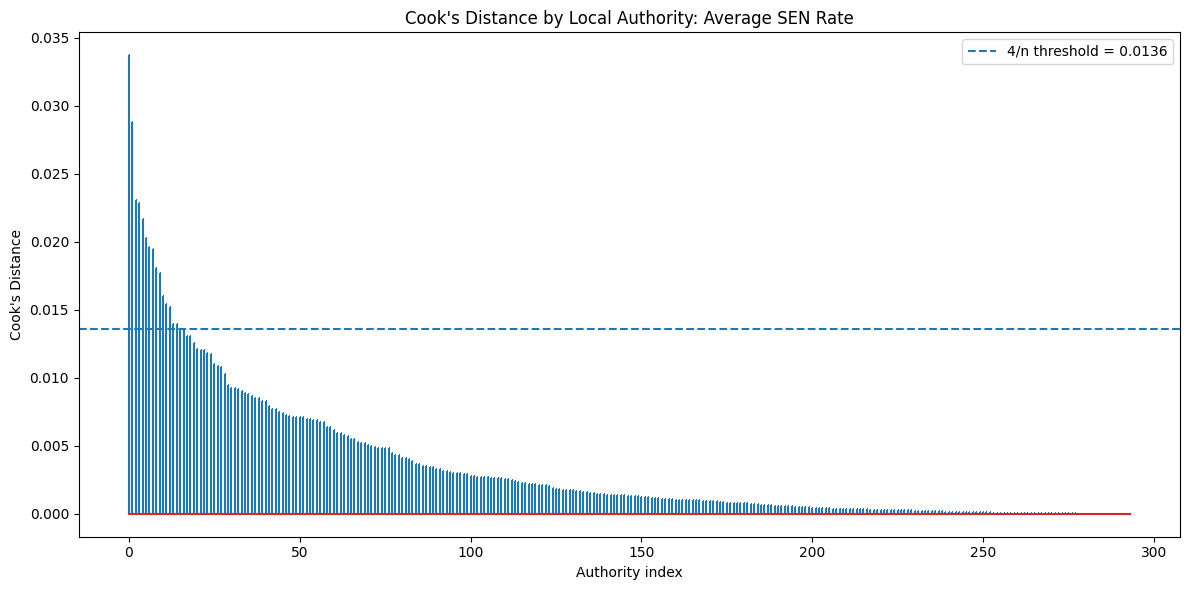

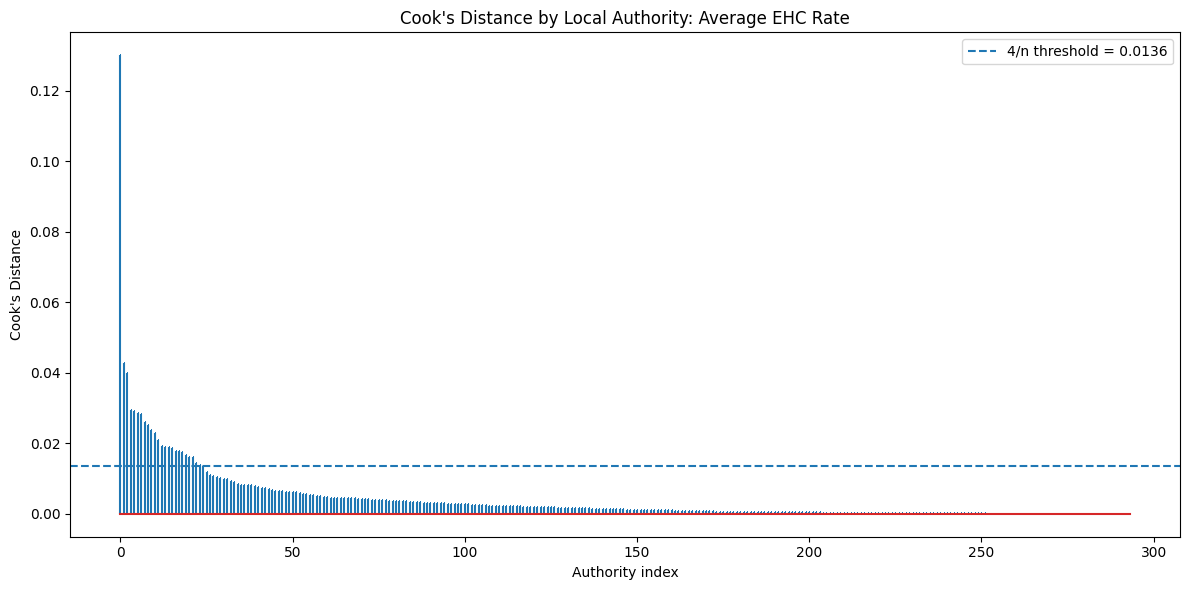

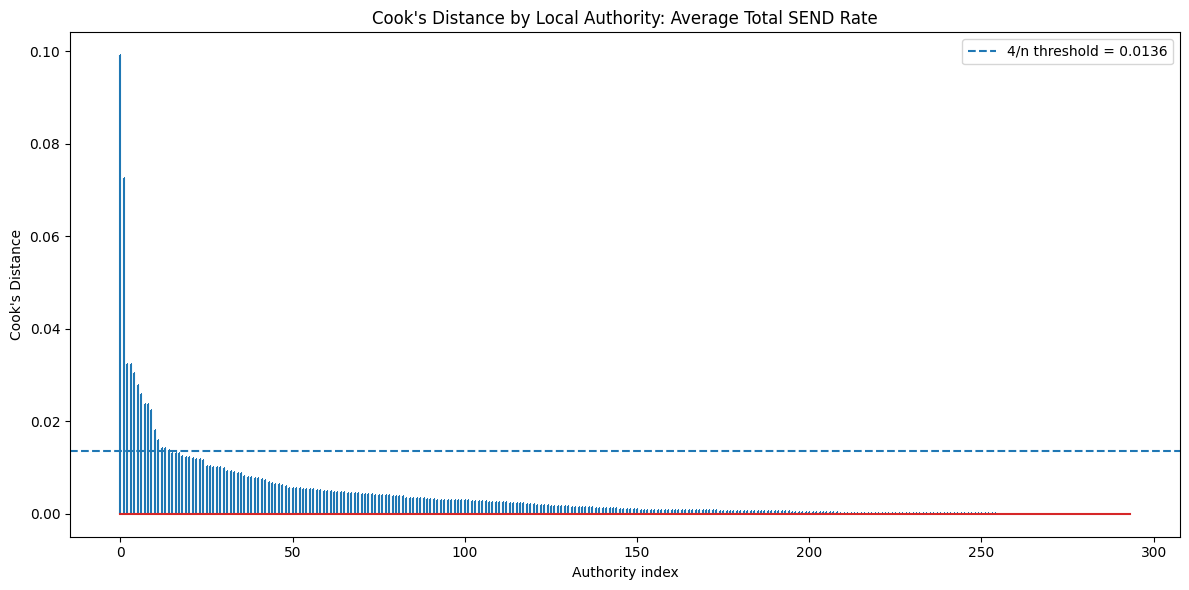

In [ ]:

 #Visualize influential-authority screening results.


for outcome, table in (
    cooks_distance_tables.items()
):

    plot_table = (
        table.reset_index(
            drop=True
        )
    )

    threshold = (
        plot_table[
            "Screening Threshold"
        ]
        .iloc[0]
    )

    plt.figure(
        figsize=(12, 6)
    )

    plt.stem(
        np.arange(
            len(
                plot_table
            )
        ),
        plot_table[
            "Cook's Distance"
        ],
        markerfmt=","
    )

    plt.axhline(
        threshold,
        linestyle="--",
        linewidth=1.5,
        label=(
            f"4/n threshold = {threshold:.4f}"
        )
    )

    plt.title(
        f"Cook's Distance by Local Authority: {outcome}"
    )

    plt.xlabel(
        "Authority index"
    )

    plt.ylabel(
        "Cook's Distance"
    )

    plt.legend()
    plt.tight_layout()
    plt.show()


# #SECTION 4.20 - EXTRACT POTENTIALLY INFLUENTIAL AUTHORITIES


In [ ]:

 #Create outcome-specific tables of authorities exceeding the
 #Cook's-Distance screening threshold.


influential_authority_tables = {}

for outcome, cooks_table in (
    cooks_distance_tables.items()
):

    influential_table = (
        cooks_table[
            cooks_table[
                "Potentially Influential"
            ]
        ]
        .copy()
    )

    influential_authority_tables[
        outcome
    ] = influential_table

    print("=" * 90)
    print(
        f"POTENTIALLY INFLUENTIAL AUTHORITIES: {outcome}"
    )
    print("=" * 90)

    print(
        "Number identified:",
        len(
            influential_table
        )
    )

    display(
        influential_table.round(
            5
        )
    )


POTENTIALLY INFLUENTIAL AUTHORITIES: Average SEN Rate
Number identified: 16


,LA Authority,district_administrative_code,Cook's Distance,Screening Threshold,Potentially Influential
200,Rushcliffe,E07000176,0.0337,0.0136,True
213,South Derbyshire,E07000039,0.0288,0.0136,True
97,Gosport,E07000088,0.0231,0.0136,True
169,North Somerset,E06000024,0.0228,0.0136,True
134,Leeds,E08000035,0.0217,0.0136,True
189,Redditch,E07000236,0.0203,0.0136,True
284,Wirral,E08000015,0.0196,0.0136,True
293,York,E06000014,0.0195,0.0136,True
93,Fylde,E07000119,0.0181,0.0136,True
99,Great Yarmouth,E07000145,0.0177,0.0136,True


POTENTIALLY INFLUENTIAL AUTHORITIES: Average EHC Rate
Number identified: 24


,LA Authority,district_administrative_code,Cook's Distance,Screening Threshold,Potentially Influential
67,Derbyshire Dales,E07000035,0.1301,0.0136,True
200,Rushcliffe,E07000176,0.0426,0.0136,True
37,Burnley,E07000117,0.0399,0.0136,True
17,Blackburn with Darwen,E06000008,0.0294,0.0136,True
21,Boston,E07000136,0.0293,0.0136,True
237,Sunderland,E08000024,0.0285,0.0136,True
126,Kensington and Chelsea,E09000020,0.0283,0.0136,True
145,Manchester,E08000003,0.0260,0.0136,True
90,Fenland,E07000010,0.0252,0.0136,True
288,Worcester,E07000237,0.0239,0.0136,True


POTENTIALLY INFLUENTIAL AUTHORITIES: Average Total SEND Rate
Number identified: 15


,LA Authority,district_administrative_code,Cook's Distance,Screening Threshold,Potentially Influential
67,Derbyshire Dales,E07000035,0.0991,0.0136,True
200,Rushcliffe,E07000176,0.0726,0.0136,True
90,Fenland,E07000010,0.0323,0.0136,True
288,Worcester,E07000237,0.0323,0.0136,True
11,Bassetlaw,E07000171,0.0303,0.0136,True
91,Folkestone and Hythe,E07000112,0.0279,0.0136,True
93,Fylde,E07000119,0.0260,0.0136,True
145,Manchester,E08000003,0.0237,0.0136,True
21,Boston,E07000136,0.0237,0.0136,True
189,Redditch,E07000236,0.0224,0.0136,True


# #SECTION 4.21 - FIT SENSITIVITY MODELS WITHOUT INFLUENTIAL CASES


In [ ]:

 #Refit each extended OLS model after temporarily excluding
 #authorities above the Cook's-Distance threshold.


sensitivity_models = {}
sensitivity_model_rows = []

for outcome, full_model in (
    diagnostic_ols_models.items()
):

    influential_codes = (
        influential_authority_tables[
            outcome
        ][
            "district_administrative_code"
        ]
        .tolist()
    )

    reduced_data = (
        diagnostic_data[
            ~diagnostic_data[
                "district_administrative_code"
            ]
            .isin(
                influential_codes
            )
        ]
        .copy()
    )

    reduced_model = smf.ols(
        formula=EXTENDED_OLS_FORMULAS[
            outcome
        ],
        data=reduced_data
    ).fit()

    sensitivity_models[
        outcome
    ] = reduced_model

    sensitivity_model_rows.extend([
        {
            "Outcome":
                outcome,

            "Model":
                "Full OLS",

            "Observations":
                int(
                    full_model.nobs
                ),

            "Influential Authorities Removed":
                0,

            "R-squared":
                full_model.rsquared,

            "Adjusted R-squared":
                full_model.rsquared_adj
        },

        {
            "Outcome":
                outcome,

            "Model":
                "Sensitivity OLS",

            "Observations":
                int(
                    reduced_model.nobs
                ),

            "Influential Authorities Removed":
                len(
                    influential_codes
                ),

            "R-squared":
                reduced_model.rsquared,

            "Adjusted R-squared":
                reduced_model.rsquared_adj
        }
    ])

sensitivity_model_table = pd.DataFrame(
    sensitivity_model_rows
)

 #Critical check: all Full OLS rows must show 294.
full_ols_counts = (
    sensitivity_model_table[
        sensitivity_model_table[
            "Model"
        ] == "Full OLS"
    ][
        "Observations"
    ]
)

if not (
    full_ols_counts
    ==
    EXPECTED_LA_COUNT
).all():

    raise ValueError(
        "Sensitivity analysis did not use 294 observations "
        "for every Full OLS model."
    )

display(
    sensitivity_model_table.round(4)
)


,Outcome,Model,Observations,Influential Authorities Removed,R-squared,Adjusted R-squared
0,Average SEN Rate,Full OLS,294,0,0.3694,0.3232
1,Average SEN Rate,Sensitivity OLS,278,16,0.3950,0.3479
2,Average EHC Rate,Full OLS,294,0,0.6959,0.6737
3,Average EHC Rate,Sensitivity OLS,270,24,0.7722,0.7539
4,Average Total SEND Rate,Full OLS,294,0,0.5834,0.5529
5,Average Total SEND Rate,Sensitivity OLS,279,15,0.6792,0.6544


# #SECTION 4.22 - COMPARE URBANITY COEFFICIENTS IN SENSITIVITY MODELS


In [ ]:

 #Assess whether Urbanity conclusions change substantially after
 #influential authorities are excluded.
#
 #Stability in sign, magnitude and significance strengthens
 #confidence in the main Urbanity findings.


urbanity_sensitivity_rows = []

for outcome in LA_OUTCOMES:

    full_model = (
        diagnostic_ols_models[
            outcome
        ]
    )

    reduced_model = (
        sensitivity_models[
            outcome
        ]
    )

    urbanity_terms = [
        term
        for term
        in full_model.params.index
        if (
            "urbanity_category"
            in term
        )
    ]

    for term in urbanity_terms:

        for model_name, model in [
            (
                "Full OLS",
                full_model
            ),
            (
                "Sensitivity OLS",
                reduced_model
            )
        ]:

            coefficient = (
                model.params.get(
                    term,
                    np.nan
                )
            )

            p_value = (
                model.pvalues.get(
                    term,
                    np.nan
                )
            )

            urbanity_sensitivity_rows.append({
                "Outcome":
                    outcome,

                "Urbanity Term":
                    term,

                "Model":
                    model_name,

                "Observations":
                    int(
                        model.nobs
                    ),

                "Coefficient":
                    coefficient,

                "Coefficient Percentage Points":
                    (
                        coefficient
                        * 100
                    ),

                "p-value":
                    p_value,

                "Statistically Significant":
                    (
                        p_value
                        < 0.05
                    )
                    if pd.notna(
                        p_value
                    )
                    else False
            })

urbanity_sensitivity_table = pd.DataFrame(
    urbanity_sensitivity_rows
)

display(
    urbanity_sensitivity_table.round(4)
)


,Outcome,Urbanity Term,Model,Observations,Coefficient,Coefficient Percentage Points,p-value,Statistically Significant
0,Average SEN Rate,"C(urbanity_category, Treatment(reference=""Most...",Full OLS,294,-0.0077,-0.7705,0.0117,True
1,Average SEN Rate,"C(urbanity_category, Treatment(reference=""Most...",Sensitivity OLS,278,-0.0056,-0.5587,0.0482,True
2,Average SEN Rate,"C(urbanity_category, Treatment(reference=""Most...",Full OLS,294,-0.0075,-0.7533,0.0374,True
3,Average SEN Rate,"C(urbanity_category, Treatment(reference=""Most...",Sensitivity OLS,278,-0.0049,-0.4895,0.1520,False
4,Average SEN Rate,"C(urbanity_category, Treatment(reference=""Most...",Full OLS,294,-0.0074,-0.7380,0.0852,False
5,Average SEN Rate,"C(urbanity_category, Treatment(reference=""Most...",Sensitivity OLS,278,-0.0057,-0.5692,0.1451,False
6,Average EHC Rate,"C(urbanity_category, Treatment(reference=""Most...",Full OLS,294,0.0018,0.1756,0.6463,False
7,Average EHC Rate,"C(urbanity_category, Treatment(reference=""Most...",Sensitivity OLS,270,0.0030,0.2953,0.3597,False
8,Average EHC Rate,"C(urbanity_category, Treatment(reference=""Most...",Full OLS,294,-0.0037,-0.3748,0.4094,False
9,Average EHC Rate,"C(urbanity_category, Treatment(reference=""Most...",Sensitivity OLS,270,0.0005,0.0525,0.8946,False


# #SECTION 4.23 - LOAD THE 2024 LA BOUNDARY GEOJSON AND JOIN TO EXCEL


In [ ]:

 #Load authoritative Local Authority geometry from the GeoJSON file
 #rather than using the incomplete geometry field in Excel.

 #REQUIRED JOIN CONDITION:

 #GeoJSON:
 #LAD24D must equal Final_LA_data.xlsx: district_administrative_code

 #The merged geographic dataset must contain all 294 LAs with no
 #missing geometry before residual spatial analysis can continue.


LA_BOUNDARY_GEOJSON_PATH = (
    "/content/drive/MyDrive/MSC Dissertation/"
    "Final Main 3/LA/LA_Boundary/"
    "2024_UK_LABoundary.geojson"
)

if not os.path.exists(
    LA_BOUNDARY_GEOJSON_PATH
):

    raise FileNotFoundError(
        "LA boundary GeoJSON not found."
        "Check LA_BOUNDARY_GEOJSON_PATH."
    )


 #Load the GeoJSON boundary file


la_boundary_gdf = gpd.read_file(
    LA_BOUNDARY_GEOJSON_PATH
)

 #Clean boundary column headings.
la_boundary_gdf.columns = (
    pd.Index(
        la_boundary_gdf.columns
    )
    .astype(str)
    .str.replace(
        "\n",
        " ",
        regex=False
    )
    .str.replace(
        r"\s+",
        " ",
        regex=True
    )
    .str.strip()
)

print(
    "GeoJSON boundary rows:",
    len(
        la_boundary_gdf
    )
)

print(
    "GeoJSON CRS:",
    la_boundary_gdf.crs
)

 #Validate required join fields


if (
    "LAD24CD"
    not in la_boundary_gdf.columns
):

    raise KeyError(
        "The GeoJSON does not contain the required LAD24CD field."
    )

if (
    "district_administrative_code"
    not in la_analysis.columns
):

    raise KeyError(
        "The final LA Excel dataset does not contain "
        "district_administrative_code."
    )


 #Normalize both administrative-code fields


la_analysis[
    "district_administrative_code"
] = (
    la_analysis[
        "district_administrative_code"
    ]
    .astype(str)
    .str.strip()
    .str.upper()
)

la_boundary_gdf[
    "LAD24CD"
] = (
    la_boundary_gdf[
        "LAD24CD"
    ]
    .astype(str)
    .str.strip()
    .str.upper()
)

 #------------------------------------------------
 #Validate Excel join-key uniqueness
 #------------------------------------------------

excel_duplicate_codes = (
    la_analysis[
        "district_administrative_code"
    ]
    .duplicated(
        keep=False
    )
)

if excel_duplicate_codes.any():

    duplicate_excel_rows = (
        la_analysis.loc[
            excel_duplicate_codes,
            [
                "LA Authority",
                "district_administrative_code"
            ]
        ]
        .sort_values(
            "district_administrative_code"
        )
    )

    display(
        duplicate_excel_rows
    )

    raise ValueError(
        "Duplicate district_administrative_code values were found "
        "in Final_LA_data.xlsx."
    )


 #Validate GeoJSON LAD24CD uniqueness


geojson_duplicate_codes = (
    la_boundary_gdf[
        "LAD24CD"
    ]
    .duplicated(
        keep=False
    )
)

if geojson_duplicate_codes.any():

    duplicate_boundary_rows = (
        la_boundary_gdf.loc[
            geojson_duplicate_codes,
            [
                "LAD24CD"
            ]
        ]
        .sort_values(
            "LAD24CD"
        )
    )

    display(
        duplicate_boundary_rows
    )

    raise ValueError(
        "Duplicate LAD24CD values were found in the GeoJSON."
    )


 #Keep only required boundary attributes


boundary_columns = [
    "LAD24CD",
    "geometry"
]

if (
    "LAD24NM"
    in la_boundary_gdf.columns
):

    boundary_columns.insert(
        1,
        "LAD24NM"
    )

boundary_lookup = (
    la_boundary_gdf[
        boundary_columns
    ]
    .copy()
)

boundary_lookup = (
    boundary_lookup.rename(
        columns={
            "LAD24CD":
                "Boundary_LAD24CD",

            "LAD24NM":
                "Boundary_LAD24NM"
        }
    )
)


 #Ignore the incomplete Excel geometry completely


excel_for_spatial_join = (
    la_analysis.drop(
        columns=[
            "geometry"
        ],
        errors="ignore"
    )
    .copy()
)


 #JOIN:
 #GeoJSON LAD24CD = Excel district_administrative_code


spatial_joined_data = (
    excel_for_spatial_join.merge(
        boundary_lookup,
        left_on=(
            "district_administrative_code"
        ),
        right_on=(
            "Boundary_LAD24CD"
        ),
        how="left",
        validate="one_to_one",
        indicator=True
    )
)

 #Report join status


join_status_table = (
    spatial_joined_data[
        "_merge"
    ]
    .value_counts(
        dropna=False
    )
    .rename_axis(
        "Join Status"
    )
    .reset_index(
        name="Number of LAs"
    )
)

display(
    join_status_table
)

unmatched_las = (
    spatial_joined_data[
        spatial_joined_data[
            "_merge"
        ]
        != "both"
    ][
        [
            "LA Authority",
            "district_administrative_code"
        ]
    ]
    .copy()
)

if not unmatched_las.empty:

    print(
        "UNMATCHED LOCAL AUTHORITIES:"
    )

    display(
        unmatched_las
    )

    raise ValueError(
        f"{len(unmatched_las)} Local Authorities did not match "
        "a GeoJSON LAD24CD boundary."
    )

 #Remove merge-status field now that validation has passed.
spatial_joined_data = (
    spatial_joined_data.drop(
        columns=[
            "_merge"
        ]
    )
)

 #Convert to GeoDataFrame using GeoJSON geometry


la_residual_gdf = gpd.GeoDataFrame(
    spatial_joined_data,
    geometry="geometry",
    crs=la_boundary_gdf.crs
)


 #Validate geometry completeness

missing_geometry_count = int(
    la_residual_gdf[
        "geometry"
    ]
    .isna()
    .sum()
)

empty_geometry_count = int(
    la_residual_gdf[
        "geometry"
    ]
    .apply(
        lambda geometry:
        geometry.is_empty
        if geometry is not None
        else False
    )
    .sum()
)

print(
    "Missing joined geometries:",
    missing_geometry_count
)

print(
    "Empty joined geometries:",
    empty_geometry_count
)

if (
    missing_geometry_count > 0
    or
    empty_geometry_count > 0
):

    problem_geometry_rows = (
        la_residual_gdf[
            la_residual_gdf[
                "geometry"
            ].isna()
            |
            la_residual_gdf[
                "geometry"
            ].apply(
                lambda geometry:
                geometry.is_empty
                if geometry is not None
                else False
            )
        ][
            [
                "LA Authority",
                "district_administrative_code",
                "Boundary_LAD24CD"
            ]
        ]
    )

    display(
        problem_geometry_rows
    )

    raise ValueError(
        "The GeoJSON join produced missing or empty geometries."
    )


 #Repair invalid geometries if necessary


invalid_geometry_count_before = int(
    (
        ~la_residual_gdf[
            "geometry"
        ]
        .is_valid
    )
    .sum()
)

print(
    "Invalid geometries before repair:",
    invalid_geometry_count_before
)

if invalid_geometry_count_before > 0:

    la_residual_gdf[
        "geometry"
    ] = (
        la_residual_gdf[
            "geometry"
        ]
        .apply(
            lambda geometry:
            make_valid(
                geometry
            )
            if not geometry.is_valid
            else geometry
        )
    )

invalid_geometry_count_after = int(
    (
        ~la_residual_gdf[
            "geometry"
        ]
        .is_valid
    )
    .sum()
)

print(
    "Invalid geometries after repair:",
    invalid_geometry_count_after
)

if invalid_geometry_count_after > 0:

    raise ValueError(
        "Some boundary geometries remain invalid after repair."
    )


 #Validate complete 294-LA join

if len(
    la_residual_gdf
) != EXPECTED_LA_COUNT:

    raise ValueError(
        f"GeoJSON-joined dataset contains "
        f"{len(la_residual_gdf)} rows instead of "
        f"{EXPECTED_LA_COUNT}."
    )

if (
    la_residual_gdf[
        "district_administrative_code"
    ]
    .nunique()
    != EXPECTED_LA_COUNT
):

    raise ValueError(
        "The GeoJSON-joined dataset does not contain 294 unique "
        "district_administrative_code values."
    )


 #Reproject to British National Grid


la_residual_gdf = (
    la_residual_gdf
    .to_crs(
        epsg=27700
    )
    .reset_index(
        drop=True
    )
)

print(
    "PASS: All 294 Local Authorities successfully joined to "
    "GeoJSON geometry."
)

print(
    "Join used: GeoJSON LAD24CD = "
    "Excel district_administrative_code"
)

print(
    "Final residual GeoDataFrame shape:",
    la_residual_gdf.shape
)

display(
    la_residual_gdf[
        [
            "LA Authority",
            "district_administrative_code",
            "Boundary_LAD24CD"
        ]
    ]
    .head()
)


GeoJSON boundary rows: 361
GeoJSON CRS: EPSG:4326


,Join Status,Number of LAs
0,both,294
1,left_only,0
2,right_only,0


Missing joined geometries: 0
Empty joined geometries: 0
Invalid geometries before repair: 0
Invalid geometries after repair: 0
PASS: All 294 Local Authorities successfully joined to GeoJSON geometry.
Join used: GeoJSON LAD24CD = Excel district_administrative_code
Final residual GeoDataFrame shape: (294, 30)


,LA Authority,district_administrative_code,Boundary_LAD24CD
0,Adur,E07000223,E07000223
1,Amber Valley,E07000032,E07000032
2,Arun,E07000224,E07000224
3,Ashfield,E07000170,E07000170
4,Ashford,E07000105,E07000105


# #SECTION 4.24 - JOIN 294-LA OLS RESIDUALS TO GEOJSON GEOGRAPHY


In [ ]:

 #Attach each OLS residual table to the newly created geographic
 #dataset.

 #The geographic dataset was created using:

 #Residuals are therefore joined using the same authoritative Excel
 #district_administrative_code field.


RESIDUAL_COLUMN_LOOKUP = {
    "Average SEN Rate":
        "SEN_Residual",

    "Average EHC Rate":
        "EHC_Residual",

    "Average Total SEND Rate":
        "Total_SEND_Residual"
}

STANDARDizeD_RESIDUAL_COLUMN_LOOKUP = {
    "Average SEN Rate":
        "SEN_Standardised_Residual",

    "Average EHC Rate":
        "EHC_Standardised_Residual",

    "Average Total SEND Rate":
        "Total_SEND_Standardised_Residual"
}

for outcome, residual_column in (
    RESIDUAL_COLUMN_LOOKUP.items()
):

    standardised_column = (
        STANDARDISED_RESIDUAL_COLUMN_LOOKUP[
            outcome
        ]
    )

    residual_join = (
        diagnostic_result_tables[
            outcome
        ][
            [
                "district_administrative_code",
                "Residual",
                "Standardised Residual"
            ]
        ]
        .rename(
            columns={
                "Residual":
                    residual_column,

                "Standardised Residual":
                    standardised_column
            }
        )
        .copy()
    )

    residual_join[
        "district_administrative_code"
    ] = (
        residual_join[
            "district_administrative_code"
        ]
        .astype(str)
        .str.strip()
        .str.upper()
    )

    la_residual_gdf = (
        la_residual_gdf.merge(
            residual_join,
            on="district_administrative_code",
            how="left",
            validate="one_to_one"
        )
    )


 #Validate residual join completeness


for residual_column in (
    list(
        RESIDUAL_COLUMN_LOOKUP.values()
    )
    +
    list(
        STANDARDISED_RESIDUAL_COLUMN_LOOKUP.values()
    )
):

    missing_count = int(
        la_residual_gdf[
            residual_column
        ]
        .isna()
        .sum()
    )

    if missing_count > 0:

        raise ValueError(
            f"{residual_column} contains {missing_count} missing "
            "values after the residual join."
        )

if len(
    la_residual_gdf
) != EXPECTED_LA_COUNT:

    raise ValueError(
        "Residual geographic dataset no longer contains 294 LAs."
    )

print(
    "PASS: Full-sample OLS residuals successfully joined to "
    "all 294 GeoJSON boundaries."
)


PASS: Full-sample OLS residuals successfully joined to all 294 GeoJSON boundaries.


# #SECTION 4.25 - CREATE SPATIAL WEIGHTS FOR ALL 294 AUTHORITIES


In [ ]:

 #Create Queen-contiguity spatial weights.

 #If disconnected authorities exist, use four-nearest-neighbour
 #weights for the complete 294-authority dataset so that no LA is
 #excluded from residual Moran analysis.


queen_weights = Queen.from_dataframe(
    la_residual_gdf,
    use_index=False
)

queen_weights.transform = "R"

print(
    "Queen islands:",
    queen_weights.islands
)

if len(
    queen_weights.islands
) == 0:

    residual_weights = (
        queen_weights
    )

    residual_weights_method = (
        "Queen contiguity"
    )

else:

    residual_weights = KNN.from_dataframe(
        la_residual_gdf,
        k=4,
        use_index=False
    )

    residual_weights.transform = "R"

    residual_weights_method = (
        "Four-nearest neighbours"
    )

print(
    "Residual spatial weights:",
    residual_weights_method
)

print(
    "Number of observations in weights:",
    residual_weights.n
)

if residual_weights.n != EXPECTED_LA_COUNT:

    raise ValueError(
        f"Spatial weights contain {residual_weights.n} "
        "observations instead of 294."
    )

print(
    "PASS: Spatial weights include all 294 authorities."
)


('WARNING: ', 124, ' is an island (no neighbors)')
Queen islands: [124]
Residual spatial weights: Four-nearest neighbours
Number of observations in weights: 294
PASS: Spatial weights include all 294 authorities.


# #SECTION 4.26 - CREATE THE DIAGNOSTIC OUTPUT FOLDER


In [ ]:



DIAGNOSTIC_OUTPUT_FOLDER = (
    "/content/drive/MyDrive/MSC Dissertation/"
    "Final Main 3/Analysis Outputs/"
    "Regression Diagnostics"
)

os.makedirs(
    DIAGNOSTIC_OUTPUT_FOLDER,
    exist_ok=True
)

DIAGNOSTIC_RESULTS_PATH = os.path.join(
    DIAGNOSTIC_OUTPUT_FOLDER,
    "LA_Regression_Diagnostic_Results.xlsx"
)

print(
    "Corrected diagnostic output folder:"
)

print(
    DIAGNOSTIC_OUTPUT_FOLDER
)


Corrected diagnostic output folder:
/content/drive/MyDrive/MSC Dissertation/Final Main 3/Analysis Outputs/Regression Diagnostics


# #SECTION 4.27 - PLOT AND SAVE FULL-SAMPLE OLS RESIDUAL MAPS


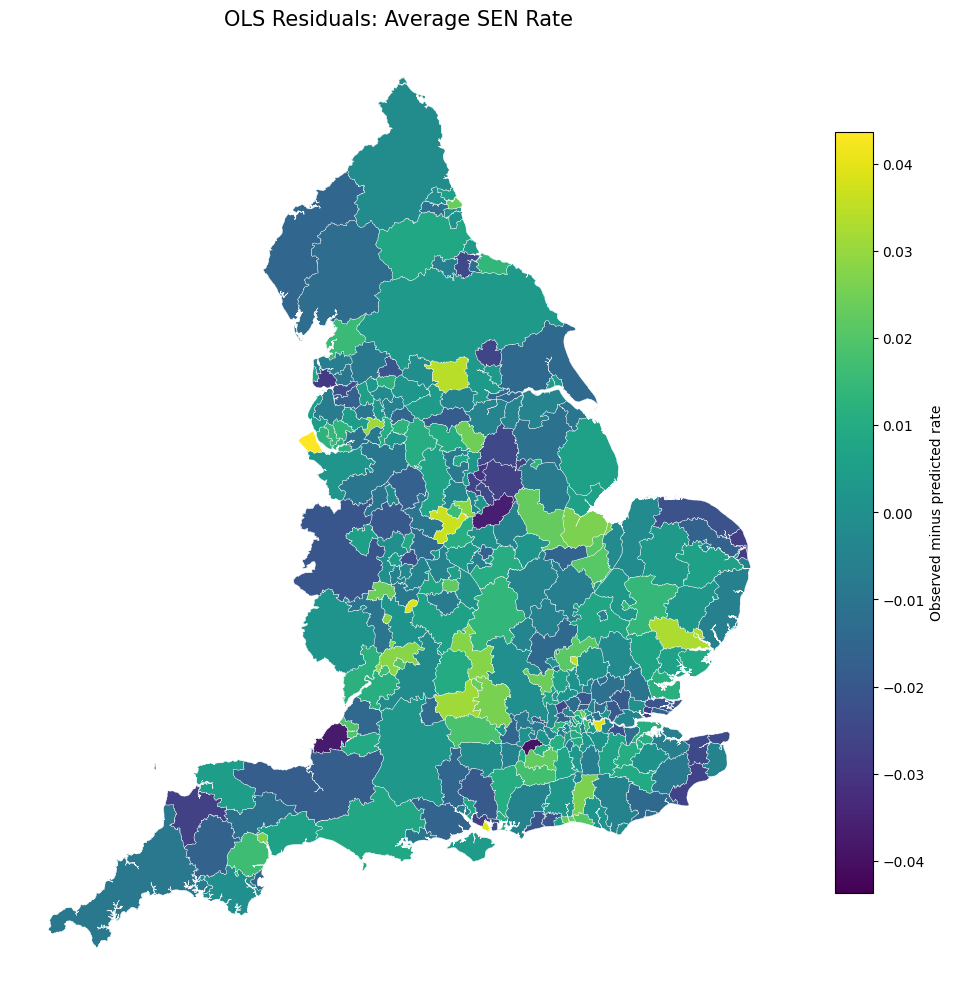

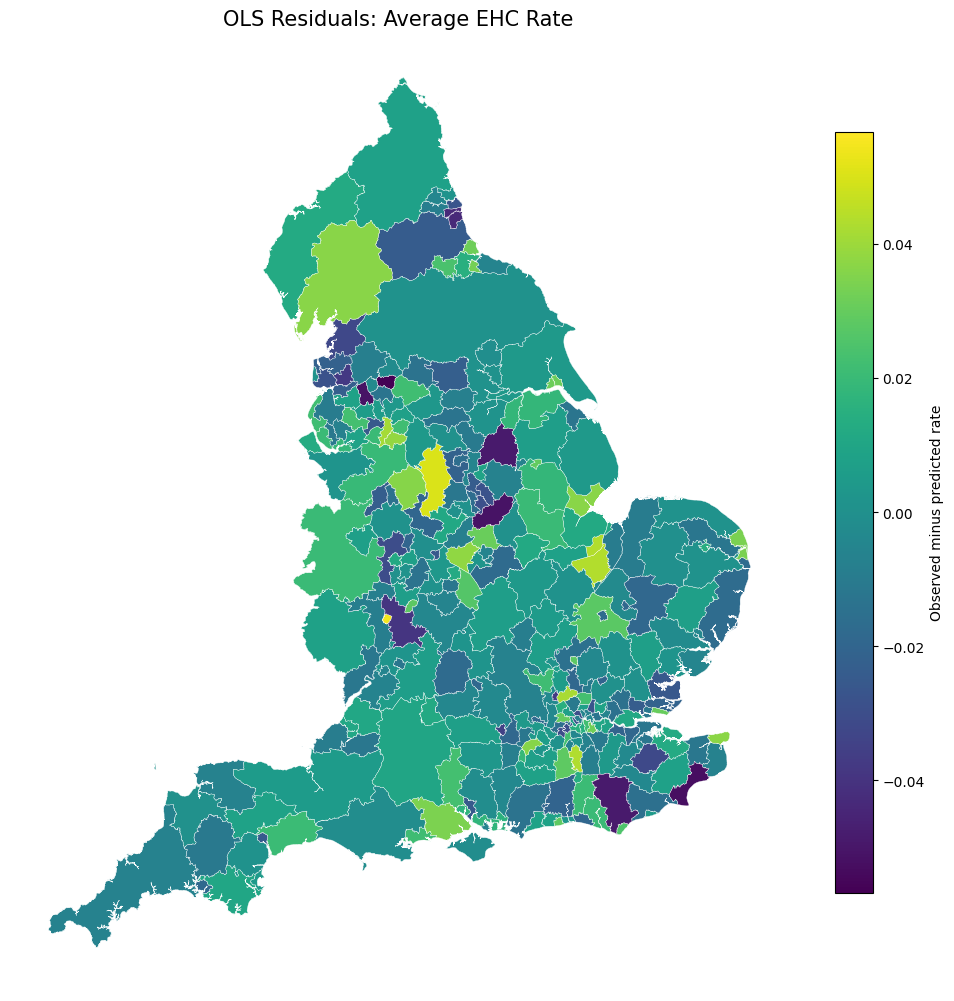

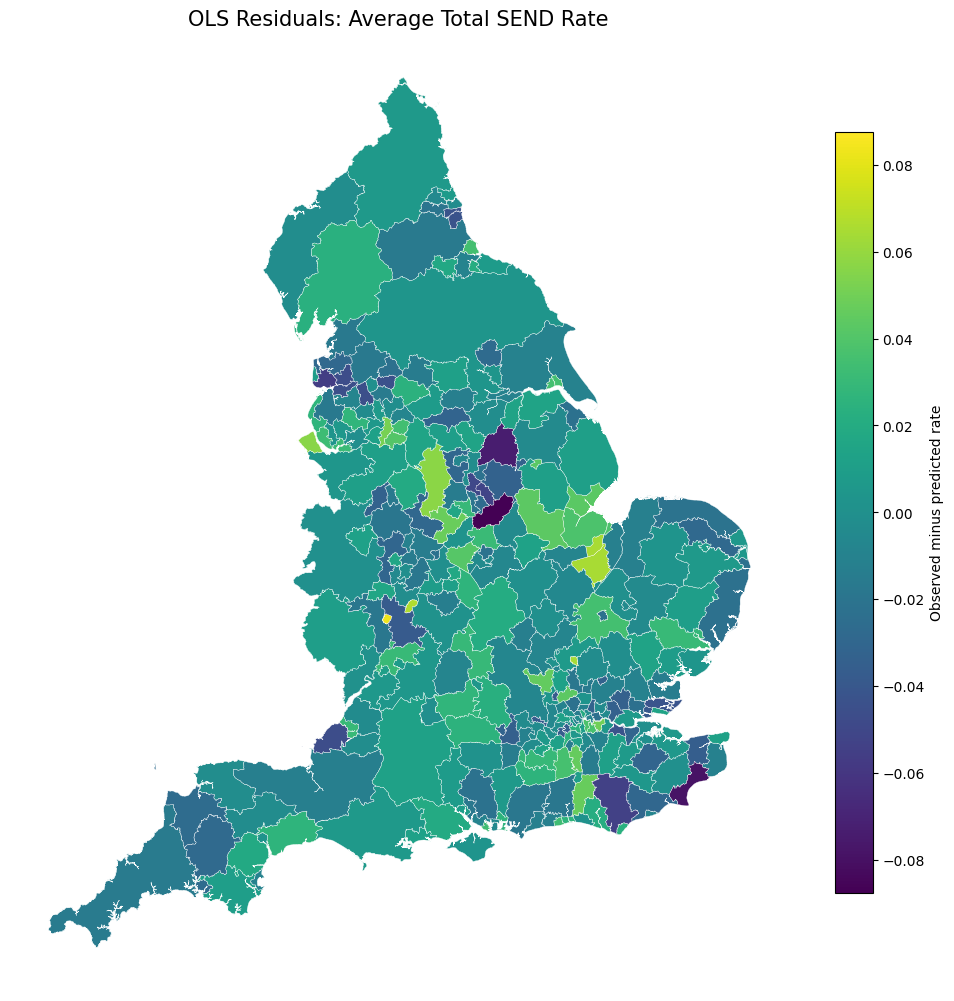

In [ ]:

 #Visualize geographic patterns of OLS underprediction and
 #overprediction using all 294 Local Authorities.

 #Positive residual:
 #Observed rate is higher than predicted.

 #Negative residual:
 #Observed rate is lower than predicted.


def plot_residual_map(
    geodataframe,
    residual_column,
    title,
    output_path
):
    """
    Plot an OLS residual map centred on zero.
    """

    maximum_absolute_value = (
        geodataframe[
            residual_column
        ]
        .abs()
        .max()
    )

    figure, axis = plt.subplots(
        figsize=(10, 12)
    )

    geodataframe.plot(
        column=residual_column,
        ax=axis,
        legend=True,
        linewidth=0.25,
        edgecolor="white",
        vmin=(
            -maximum_absolute_value
        ),
        vmax=(
            maximum_absolute_value
        ),
        legend_kwds={
            "label":
                "Observed minus predicted rate",

            "shrink":
                0.65
        }
    )

    axis.set_title(
        title,
        fontsize=15
    )

    axis.set_axis_off()

    plt.tight_layout()

    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


for outcome, residual_column in (
    RESIDUAL_COLUMN_LOOKUP.items()
):

    map_path = os.path.join(
        DIAGNOSTIC_OUTPUT_FOLDER,
        f"{residual_column}_Map.png"
    )

    plot_residual_map(
        geodataframe=la_residual_gdf,
        residual_column=residual_column,
        title=(
            f"OLS Residuals: {outcome}"
        ),
        output_path=map_path
    )


# #SECTION 4.28 - CALCULATE GLOBAL MORAN'S I OF FULL-SAMPLE RESIDUALS


In [ ]:

 #Test whether unexplained OLS residuals remain spatially clustered
 #after the full 294-authority regression models.

 #Significant positive residual Moran's I:
 #Geographic structure remains unexplained.

 #Non-significant residual Moran's I:
 #The included predictors account for much of the broad spatial structure.


residual_moran_objects = {}
residual_moran_rows = []

for outcome, residual_column in (
    RESIDUAL_COLUMN_LOOKUP.items()
):

    residual_values = (
        la_residual_gdf[
            residual_column
        ]
        .astype(float)
        .to_numpy()
    )

    if len(
        residual_values
    ) != EXPECTED_LA_COUNT:

        raise ValueError(
            f"{outcome} residual Moran input has "
            f"{len(residual_values)} observations instead of 294."
        )

    moran_result = Moran(
        residual_values,
        residual_weights,
        permutations=999
    )

    residual_moran_objects[
        outcome
    ] = moran_result

    if (
        moran_result.p_sim < 0.05
        and
        moran_result.I > 0
    ):

        interpretation = (
            "Significant residual spatial clustering"
        )

    elif (
        moran_result.p_sim < 0.05
        and
        moran_result.I < 0
    ):

        interpretation = (
            "Significant residual spatial dispersion"
        )

    else:

        interpretation = (
            "No significant residual spatial autocorrelation"
        )

    residual_moran_rows.append({
        "Outcome":
            outcome,

        "Observations":
            EXPECTED_LA_COUNT,

        "Residual Column":
            residual_column,

        "Moran's I":
            moran_result.I,

        "Expected I":
            moran_result.EI,

        "Permutation p-value":
            moran_result.p_sim,

        "Z-score":
            moran_result.z_sim,

        "Spatial Weights Method":
            residual_weights_method,

        "Interpretation":
            interpretation
    })

residual_moran_table = pd.DataFrame(
    residual_moran_rows
)

display(
    residual_moran_table.round(4)
)


,Outcome,Observations,Residual Column,Moran's I,Expected I,Permutation p-value,Z-score,Spatial Weights Method,Interpretation
0,Average SEN Rate,294,SEN_Residual,0.1779,-0.0034,0.0010,4.7712,Four-nearest neighbours,Significant residual spatial clustering
1,Average EHC Rate,294,EHC_Residual,0.0617,-0.0034,0.0650,1.6368,Four-nearest neighbours,No significant residual spatial autocorrelation
2,Average Total SEND Rate,294,Total_SEND_Residual,0.1756,-0.0034,0.0010,4.5614,Four-nearest neighbours,Significant residual spatial clustering


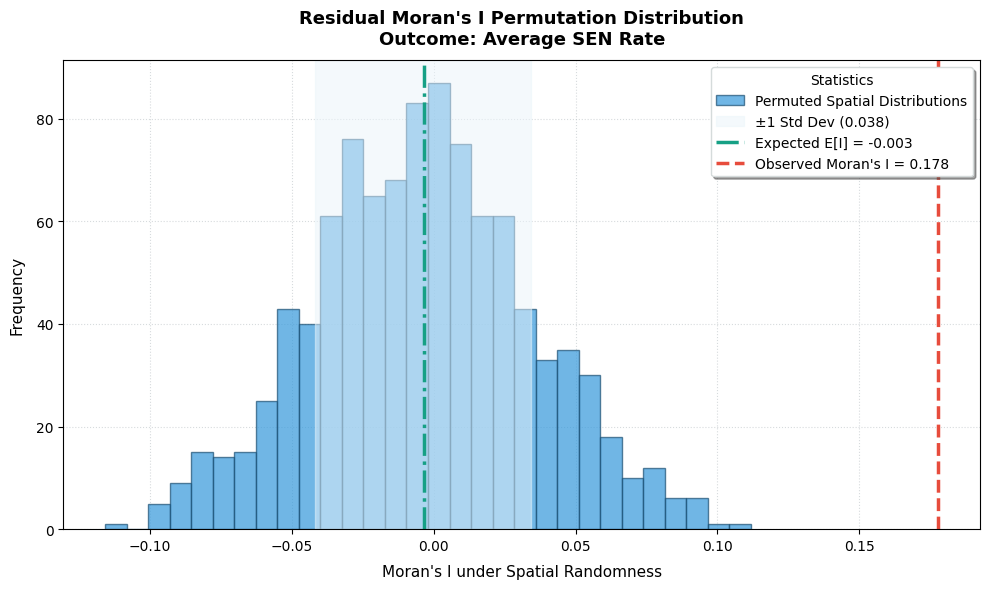

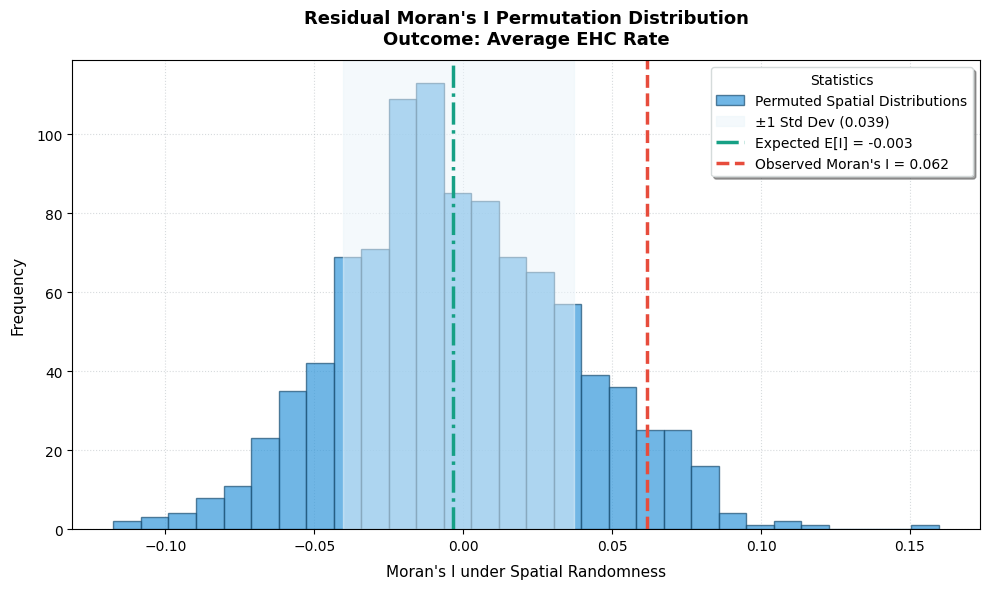

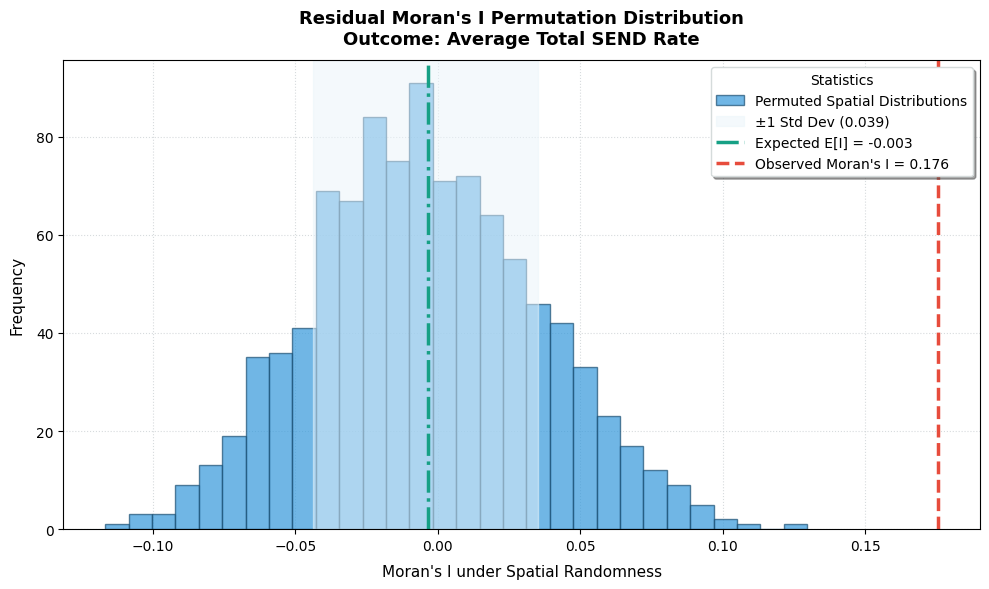

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


 #Compare the observed residual Moran's I with the distribution
 #expected under 999 random spatial permutations.


for outcome, moran_result in residual_moran_objects.items():

    fig, ax = plt.subplots(figsize=(10, 6))

     #1.Histogram of Permutations (Vibrant Blue with dark borders)
    n, bins, patches = ax.hist(
        moran_result.sim,
        bins=30,
        color="#3498db",         #Vibrant Blue fill
        edgecolor="#1b4f72",     #Dark Blue border
        alpha=0.7,
        label="Permuted Spatial Distributions"
    )



     #2.Shaded Region for Permutation Spread (+/ -1 Std Dev)
    sim_mean = np.mean(moran_result.sim)
    sim_std = np.std(moran_result.sim)
    ax.axvspan(
        sim_mean  -sim_std,
        sim_mean + sim_std,
        color="#ebf5fb",
        alpha=0.5,
        label=f"±1 Std Dev ({sim_std:.3f})"
    )

     #3.Expected Value Line (Teal / Cyan Dot-Dash)
    ax.axvline(
        moran_result.EI,
        color="#16a085",
        linestyle="-.",
        linewidth=2.5,
        label=f"Expected E[I] = {moran_result.EI:.3f}"
    )

     #4.Observed Moran's I Line (Bright Crimson Red)
    ax.axvline(
        moran_result.I,
        color="#e74c3c",
        linestyle="--",
        linewidth=2.5,
        label=f"Observed Moran's I = {moran_result.I:.3f}"
    )

     #5.Titles and Labels
    ax.set_title(
        f"Residual Moran's I Permutation Distribution\nOutcome: {outcome}",
        fontsize=13,
        fontweight="bold",
        pad=12
    )
    ax.set_xlabel("Moran's I under Spatial Randomness", fontsize=11, labelpad=8)
    ax.set_ylabel("Frequency", fontsize=11, labelpad=8)

     #6.Grid and Aesthetics
    ax.grid(True, linestyle=":", alpha=0.6, color="#bdc3c7")
    ax.set_axisbelow(True)   #Grid behind bars

     #7.Enhanced Legend
    ax.legend(
        loc="upper right",
        frameon=True,
        facecolor="#ffffff",
        edgecolor="#d5dbdb",
        shadow=True,
        fontsize=10,
        title="Statistics",
        title_fontsize=10
    )

    plt.tight_layout()
    plt.show()

# #SECTION 4.30 - CALCULATE LOCAL MORAN'S I OF FULL-SAMPLE RESIDUALS


In [ ]:

 #Identify local clusters of OLS underprediction and overprediction
 #using all 294 authorities.

 #High-High:
 #Positive residuals surrounded by positive residuals.

 #Low-Low:
 #Negative residuals surrounded by negative residuals.

 #High-Low / Low-High:
 #Local residual spatial outliers.


RESIDUAL_QUADRANT_LABELS = {
    1:
        "High-High",

    2:
        "Low-High",

    3:
        "Low-Low",

    4:
        "High-Low"
}

local_residual_tables = {}

for outcome, residual_column in (
    RESIDUAL_COLUMN_LOOKUP.items()
):

    values = (
        la_residual_gdf[
            residual_column
        ]
        .astype(float)
        .to_numpy()
    )

    local_moran = Moran_Local(
        values,
        residual_weights,
        permutations=999
    )

    local_table = (
        la_residual_gdf[
            [
                "LA Authority",
                "district_administrative_code",
                "Boundary_LAD24CD",
                residual_column
            ]
        ]
        .copy()
    )

    local_table[
        "Local Moran I"
    ] = local_moran.Is

    local_table[
        "Local Moran p-value"
    ] = local_moran.p_sim

    local_table[
        "Residual Quadrant"
    ] = [
        RESIDUAL_QUADRANT_LABELS.get(
            quadrant,
            "Unclassified"
        )
        for quadrant in local_moran.q
    ]

    local_table[
        "Residual Cluster"
    ] = np.where(
        local_table[
            "Local Moran p-value"
        ] < 0.05,
        local_table[
            "Residual Quadrant"
        ],
        "Not Significant"
    )

    if len(
        local_table
    ) != EXPECTED_LA_COUNT:

        raise ValueError(
            f"Local residual table for {outcome} contains "
            f"{len(local_table)} rows instead of 294."
        )

    local_residual_tables[
        outcome
    ] = local_table

    print("=" * 90)
    print(
        f"LOCAL RESIDUAL CLUSTERS: {outcome}"
    )
    print("=" * 90)

    display(
        local_table[
            "Residual Cluster"
        ]
        .value_counts()
        .rename_axis(
            "Residual Cluster"
        )
        .reset_index(
            name="Number of LAs"
        )
    )


LOCAL RESIDUAL CLUSTERS: Average SEN Rate


,Residual Cluster,Number of LAs
0,Not Significant,245
1,High-High,21
2,Low-Low,15
3,High-Low,7
4,Low-High,6


LOCAL RESIDUAL CLUSTERS: Average EHC Rate


,Residual Cluster,Number of LAs
0,Not Significant,246
1,Low-Low,17
2,High-High,13
3,High-Low,11
4,Low-High,7


LOCAL RESIDUAL CLUSTERS: Average Total SEND Rate


,Residual Cluster,Number of LAs
0,Not Significant,241
1,Low-Low,23
2,High-High,16
3,High-Low,7
4,Low-High,7


# #SECTION 4.31 - IDENTIFY SIGNIFICANT RESIDUAL CLUSTERS


In [ ]:

 #List authorities contributing to statistically significant
 #geographic clusters of underprediction or overprediction.

 #Residual clustering may indicate unmeasured local influences, but
 #does not by itself prove unfair SEND provision.


significant_residual_cluster_tables = {}

for outcome, local_table in (
    local_residual_tables.items()
):

    significant_table = (
        local_table[
            local_table[
                "Residual Cluster"
            ]
            != "Not Significant"
        ]
        .copy()
        .sort_values(
            [
                "Residual Cluster",
                "Local Moran p-value"
            ]
        )
    )

    significant_residual_cluster_tables[
        outcome
    ] = significant_table

    print("=" * 90)
    print(
        f"SIGNIFICANT RESIDUAL CLUSTERS: {outcome}"
    )
    print("=" * 90)

    print(
        "Number of significant residual-cluster LAs:",
        len(
            significant_table
        )
    )

    display(
        significant_table.drop(
            columns="geometry",
            errors="ignore"
        ).round(5)
    )


SIGNIFICANT RESIDUAL CLUSTERS: Average SEN Rate
Number of significant residual-cluster LAs: 49


,LA Authority,district_administrative_code,Boundary_LAD24CD,SEN_Residual,Local Moran I,Local Moran p-value,Residual Quadrant,Residual Cluster
180,Oxford,E07000178,E07000178,0.0234,2.3742,0.0020,High-High,High-High
131,Knowsley,E08000011,E08000011,0.0146,1.2745,0.0050,High-High,High-High
140,Liverpool,E08000012,E08000012,0.0126,1.1288,0.0050,High-High,High-High
247,Tendring,E07000076,E07000076,0.0090,0.8115,0.0050,High-High,High-High
276,West Oxfordshire,E07000181,E07000181,0.0096,0.8327,0.0050,High-High,High-High
92,Forest of Dean,E07000080,E07000080,0.0119,0.9742,0.0110,High-High,High-High
96,Gloucester,E07000081,E07000081,0.0162,1.2503,0.0120,High-High,High-High
151,Mid Suffolk,E07000203,E07000203,0.0029,0.2050,0.0170,High-High,High-High
136,Lewes,E07000063,E07000063,0.0016,0.1140,0.0180,High-High,High-High
55,Colchester,E07000071,E07000071,0.0065,0.4296,0.0230,High-High,High-High


SIGNIFICANT RESIDUAL CLUSTERS: Average EHC Rate
Number of significant residual-cluster LAs: 48


,LA Authority,district_administrative_code,Boundary_LAD24CD,EHC_Residual,Local Moran I,Local Moran p-value,Residual Quadrant,Residual Cluster
216,South Holland,E07000140,E07000140,0.0116,0.8503,0.0050,High-High,High-High
242,Tameside,E08000008,E08000008,0.0218,1.3329,0.0100,High-High,High-High
165,North Kesteven,E07000139,E07000139,0.0182,0.9811,0.0120,High-High,High-High
232,Stockport,E08000007,E08000007,0.0382,2.2583,0.0120,High-High,High-High
60,Crawley,E07000226,E07000226,0.0141,0.8051,0.0170,High-High,High-High
233,Stockton-on-Tees,E06000004,E06000004,0.0148,0.8358,0.0190,High-High,High-High
179,Oldham,E08000004,E08000004,0.0073,0.3566,0.0230,High-High,High-High
182,Peterborough,E06000031,E06000031,0.0075,0.3450,0.0330,High-High,High-High
116,High Peak,E07000037,E07000037,0.0041,0.1862,0.0430,High-High,High-High
110,Hartlepool,E06000001,E06000001,0.0319,1.4305,0.0440,High-High,High-High


SIGNIFICANT RESIDUAL CLUSTERS: Average Total SEND Rate
Number of significant residual-cluster LAs: 53


,LA Authority,district_administrative_code,Boundary_LAD24CD,Total_SEND_Residual,Local Moran I,Local Moran p-value,Residual Quadrant,Residual Cluster
29,Brighton and Hove,E06000043,E06000043,0.0015,0.0767,0.0030,High-High,High-High
131,Knowsley,E08000011,E08000011,0.0034,0.1668,0.0030,High-High,High-High
172,North West Leicestershire,E07000134,E07000134,0.0027,0.1456,0.0040,High-High,High-High
216,South Holland,E07000140,E07000140,0.0379,2.1417,0.0040,High-High,High-High
141,Luton,E06000032,E06000032,0.0007,0.0331,0.0060,High-High,High-High
60,Crawley,E07000226,E07000226,0.0097,0.4393,0.0090,High-High,High-High
21,Boston,E07000136,E07000136,0.0430,1.7366,0.0110,High-High,High-High
232,Stockport,E08000007,E08000007,0.0405,1.8084,0.0140,High-High,High-High
132,Lambeth,E09000022,E09000022,0.0101,0.4184,0.0170,High-High,High-High
140,Liverpool,E08000012,E08000012,0.0326,1.2449,0.0280,High-High,High-High


# #SECTION 4.32 - CREATE THE CORRECTED DIAGNOSTIC SUMMARY


In [ ]:

 #Summarize:
 #-heteroscedasticity;
 #-multicollinearity;
 #-influential authorities;
 #-residual spatial clustering;
 #-model sample size.




diagnostic_summary_rows = []

for outcome in LA_OUTCOMES:

    bp_row = (
        breusch_pagan_table[
            breusch_pagan_table[
                "Outcome"
            ] == outcome
        ]
        .iloc[0]
    )

    vif_table = (
        vif_tables[
            outcome
        ]
    )

    cooks_table = (
        cooks_distance_tables[
            outcome
        ]
    )

    moran_row = (
        residual_moran_table[
            residual_moran_table[
                "Outcome"
            ] == outcome
        ]
        .iloc[0]
    )

    diagnostic_summary_rows.append({
        "Outcome":
            outcome,

        "Observations":
            EXPECTED_LA_COUNT,

        "Breusch-Pagan p-value":
            bp_row[
                "LM p-value"
            ],

        "Heteroscedasticity":
            bp_row[
                "Interpretation"
            ],

        "Maximum VIF":
            vif_table[
                "VIF"
            ].max(),

        "Number of Predictors with VIF >= 5":
            int(
                (
                    vif_table[
                        "VIF"
                    ] >= 5
                )
                .sum()
            ),

        "Number of Influential Authorities":
            int(
                cooks_table[
                    "Potentially Influential"
                ]
                .sum()
            ),

        "Residual Moran's I":
            moran_row[
                "Moran's I"
            ],

        "Residual Moran p-value":
            moran_row[
                "Permutation p-value"
            ],

        "Residual Spatial Interpretation":
            moran_row[
                "Interpretation"
            ]
    })

diagnostic_summary_table = pd.DataFrame(
    diagnostic_summary_rows
)

display(
    diagnostic_summary_table.round(4)
)


,Outcome,Observations,Breusch-Pagan p-value,Heteroscedasticity,Maximum VIF,Number of Predictors with VIF >= 5,Number of Influential Authorities,Residual Moran's I,Residual Moran p-value,Residual Spatial Interpretation
0,Average SEN Rate,294,0.5695,No significant evidence of heteroscedasticity,147.3929,6,16,0.1779,0.0010,Significant residual spatial clustering
1,Average EHC Rate,294,0.1026,No significant evidence of heteroscedasticity,147.3929,6,24,0.0617,0.0650,No significant residual spatial autocorrelation
2,Average Total SEND Rate,294,0.2262,No significant evidence of heteroscedasticity,147.3929,6,15,0.1756,0.0010,Significant residual spatial clustering


# #SECTION 4.33 - FINAL FULL-SAMPLE VALIDATION CHECK


In [ ]:

 #Perform one last explicit validation before saving outputs.

 #The corrected notebook is valid only when:
 #-final LA dataset = 294;
 #-each full OLS model = 294;
 #-each residual table = 294;
 #-each Cook's table = 294;
 #-spatial weights = 294;
 #-each Local Moran table = 294.


validation_rows = []

validation_rows.append({
    "Component":
        "Final LA dataset",

    "Observed Count":
        len(
            la_analysis
        ),

    "Expected Count":
        EXPECTED_LA_COUNT
})

for outcome in LA_OUTCOMES:

    validation_rows.extend([
        {
            "Component":
                f"OLS model - {outcome}",

            "Observed Count":
                int(
                    diagnostic_ols_models[
                        outcome
                    ].nobs
                ),

            "Expected Count":
                EXPECTED_LA_COUNT
        },

        {
            "Component":
                f"Residual table - {outcome}",

            "Observed Count":
                len(
                    diagnostic_result_tables[
                        outcome
                    ]
                ),

            "Expected Count":
                EXPECTED_LA_COUNT
        },

        {
            "Component":
                f"Cook's table - {outcome}",

            "Observed Count":
                len(
                    cooks_distance_tables[
                        outcome
                    ]
                ),

            "Expected Count":
                EXPECTED_LA_COUNT
        },

        {
            "Component":
                f"Local Moran table - {outcome}",

            "Observed Count":
                len(
                    local_residual_tables[
                        outcome
                    ]
                ),

            "Expected Count":
                EXPECTED_LA_COUNT
        }
    ])

validation_rows.append({
    "Component":
        "Spatial weights",

    "Observed Count":
        residual_weights.n,

    "Expected Count":
        EXPECTED_LA_COUNT
})

final_sample_validation_table = pd.DataFrame(
    validation_rows
)

final_sample_validation_table[
    "PASS"
] = (
    final_sample_validation_table[
        "Observed Count"
    ]
    ==
    final_sample_validation_table[
        "Expected Count"
    ]
)

display(
    final_sample_validation_table
)

if not final_sample_validation_table[
    "PASS"
].all():

    raise ValueError(
        "FINAL VALIDATION FAILED."
        "Do not use or export the diagnostic results."
    )

print(
    "PASS: Every full-sample Section 5 component uses all 294 LAs."
)


,Component,Observed Count,Expected Count,PASS
0,Final LA dataset,294,294,True
1,OLS model — Average SEN Rate,294,294,True
2,Residual table — Average SEN Rate,294,294,True
3,Cook's table — Average SEN Rate,294,294,True
4,Local Moran table — Average SEN Rate,294,294,True
5,OLS model — Average EHC Rate,294,294,True
6,Residual table — Average EHC Rate,294,294,True
7,Cook's table — Average EHC Rate,294,294,True
8,Local Moran table — Average EHC Rate,294,294,True
9,OLS model — Average Total SEND Rate,294,294,True


PASS: Every full-sample Section 5 component uses all 294 LAs.


# #SECTION 4.34 - EXPORT CORRECTED DIAGNOSTIC RESULTS TO EXCEL


In [ ]:

 #Save the corrected 294-LA diagnostics using the exact workbook
 #name expected by Sections 7 and 8:


with pd.ExcelWriter(
    DIAGNOSTIC_RESULTS_PATH,
    engine="openpyxl"
) as writer:

    final_sample_validation_table.to_excel(
        writer,
        sheet_name="Sample Validation",
        index=False
    )

    residual_distribution_table.to_excel(
        writer,
        sheet_name="Residual Distribution",
        index=False
    )

    breusch_pagan_table.to_excel(
        writer,
        sheet_name="Breusch Pagan",
        index=False
    )

    high_vif_table.to_excel(
        writer,
        sheet_name="High VIF Predictors",
        index=False
    )

    sensitivity_model_table.to_excel(
        writer,
        sheet_name="Sensitivity Models",
        index=False
    )

    urbanity_sensitivity_table.to_excel(
        writer,
        sheet_name="Urbanity Sensitivity",
        index=False
    )

    residual_moran_table.to_excel(
        writer,
        sheet_name="Residual Morans I",
        index=False
    )

    diagnostic_summary_table.to_excel(
        writer,
        sheet_name="Diagnostic Summary",
        index=False
    )

    for outcome in LA_OUTCOMES:

        short_name = (
            outcome
            .replace(
                "Average ",
                ""
            )
            .replace(
                " Rate",
                ""
            )
            .replace(
                "Total SEND",
                "Total"
            )
        )

        vif_tables[
            outcome
        ].to_excel(
            writer,
            sheet_name=(
                f"VIF {short_name}"
            )[:31],
            index=False
        )

        cooks_distance_tables[
            outcome
        ].to_excel(
            writer,
            sheet_name=(
                f"Cooks {short_name}"
            )[:31],
            index=False
        )

        diagnostic_result_tables[
            outcome
        ].to_excel(
            writer,
            sheet_name=(
                f"Residuals {short_name}"
            )[:31],
            index=False
        )

        significant_residual_cluster_tables[
            outcome
        ].drop(
            columns="geometry",
            errors="ignore"
        ).to_excel(
            writer,
            sheet_name=(
                f"Spatial Resid {short_name}"
            )[:31],
            index=False
        )

print(
    "Corrected diagnostic workbook saved:"
)

print(
    DIAGNOSTIC_RESULTS_PATH
)


Corrected diagnostic workbook saved:
/content/drive/MyDrive/MSC Dissertation/Final Main 3/Analysis Outputs/Regression Diagnostics/LA_Regression_Diagnostic_Results.xlsx


# #SECTION 4.35 - SAVE CORRECTED GEOGRAPHIC RESIDUAL RESULTS


In [ ]:


RESIDUAL_GEOPACKAGE_PATH = os.path.join(
    DIAGNOSTIC_OUTPUT_FOLDER,
    "LA_OLS_Residual_Spatial_Results.gpkg"
)

la_residual_gdf.to_file(
    RESIDUAL_GEOPACKAGE_PATH,
    layer="ols_residuals",
    driver="GPKG"
)

print(
    "Corrected residual geographic results saved:"
)

print(
    RESIDUAL_GEOPACKAGE_PATH
)


Corrected residual geographic results saved:
/content/drive/MyDrive/MSC Dissertation/Final Main 3/Analysis Outputs/Regression Diagnostics/LA_OLS_Residual_Spatial_Results.gpkg
